# 04 — Modelado SARIMA: Pronóstico Estacional de Rentas Cedidas

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Carga y preparación de la serie Oct 2021 – Dic 2025 | Split temporal, log1p, gestión de negativos |
| **II** | Análisis de estacionariedad | ADF + KPSS + diferenciación estacional |
| **III** | Identificación de parámetros | ACF / PACF + validación de hipótesis de rezagos |
| **IV** | Búsqueda en rejilla | Grid Search minimizando AICc |
| **V** | Modelo óptimo y diagnóstico | Coeficientes, Ljung-Box, Shapiro-Wilk, homocedasticidad |
| **VI** | Pronóstico | Out-of-sample (3m) + producción (12m, 2026) |

### Justificación Metodológica

**Periodo de análisis:** Se utiliza la serie completa Oct 2021 – Sep 2025
(48 meses) como conjunto de entrenamiento, reservando Oct–Dic 2025 (3 meses)
para validación out-of-sample. Esto maximiza la información disponible para
la estimación estacional, incluyendo los 4+ ciclos anuales completos.

**Estabilización de varianza:** La serie original presenta asimetría y variabilidad
importante (CV ≈ 0.34). Se aplica transformación log1p antes del modelado para
mitigar outliers de alto volumen y facilitar la convergencia de residuos hacia
la normalidad.

**Gestión de negativos:** Los registros negativos corresponden a ajustes contables
legítimos de ADRES y se mantienen en la serie neta como parte de la dinámica
administrativa real.

> **Referencia cruzada:** Hallazgos de estacionalidad (NB 02, F_s = 0.90),
> estacionariedad (d=1 suficiente) y correlación macro (NB 03, lag-12 dominante).

In [1]:
# ══════════════════════════════════════════════════════════════
# SETUP — Configuración, Imports y Carga de Datos
# ══════════════════════════════════════════════════════════════

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)

# ── Carga de serie mensual procesada ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

print(f"Serie mensual cargada: {len(df_serie)} observaciones")
print(f"  Rango: {df_serie.index.min().date()} → {df_serie.index.max().date()}")
print(f"  Columnas: {list(df_serie.columns)}")
print(f"  Fuente: {csv_path.name}")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasVF_limpieza21feb_sin2021_ene_sep.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


Serie mensual cargada: 51 observaciones
  Rango: 2021-10-01 → 2025-12-01
  Columnas: ['Recaudo_Total', 'Recaudo_Real', 'IPC_Indice', 'YoY', 'YoY_Real', 'Año', 'Mes']
  Fuente: serie_mensual.csv


---

## Fase I — Carga y Preparación de la Serie Mensual

### Estrategia de Partición Temporal

Se utiliza toda la serie disponible para maximizar la información:

1. **Train (Oct 2021 – Sep 2025):** 48 meses que incluyen 4 ciclos anuales
   completos de estacionalidad, capturando la dinámica post-pandemia completa.
2. **Test (Oct – Dic 2025):** 3 meses reservados exclusivamente para
   validación out-of-sample del pronóstico y cuantificación de errores.
3. **Gestión de negativos:** Los registros negativos corresponden a ajustes
   contables legítimos y se mantienen en la serie neta.

> **Resultado:** Split 48/3 (94%/6%) que aprovecha toda la información
> disponible y reserva un trimestre completo para validación.

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I-a — Preparación de la Serie y Split Temporal
# ══════════════════════════════════════════════════════════════

# ── Serie completa Oct 2021 – Dic 2025 ──
serie_full = df_serie['Recaudo_Total'].copy()
serie_full.name = 'Recaudo_Total'

# ── Split Train/Test ──
# Train: Oct 2021 – Sep 2025 (48 meses)
# Test:  Oct 2025 – Dic 2025 (3 meses para validación)
train = serie_full.loc[:'2025-09-30']
test  = serie_full.loc['2025-10-01':]
serie = serie_full.copy()  # serie completa para referencia

print(f"{'═'*70}")
print(f"PREPARACIÓN DE LA SERIE PARA MODELADO SARIMA")
print(f"{'═'*70}")
print(f"  Serie completa: {len(serie_full)} meses ({serie_full.index.min().date()} → {serie_full.index.max().date()})")
print(f"  Entrenamiento:  {len(train)} meses ({train.index.min().date()} → {train.index.max().date()})")
print(f"  Prueba:         {len(test)} meses ({test.index.min().date()} → {test.index.max().date()})")

# ── Estadísticas descriptivas (sobre train) ──
print(f"\n{'─'*70}")
print(f"ESTADÍSTICAS DESCRIPTIVAS — Entrenamiento Oct 2021 – Sep 2025")
print(f"{'─'*70}")
print(f"  Media:    ${train.mean()/1e9:,.1f} MM COP")
print(f"  Mediana:  ${train.median()/1e9:,.1f} MM COP")
print(f"  Std:      ${train.std()/1e9:,.1f} MM COP")
print(f"  CV:       {train.std()/train.mean():.4f}")
print(f"  Mínimo:   ${train.min()/1e9:,.1f} MM ({train.idxmin().strftime('%Y-%m')})")
print(f"  Máximo:   ${train.max()/1e9:,.1f} MM ({train.idxmax().strftime('%Y-%m')})")
print(f"  Asimetría: {stats.skew(train.values):.4f}")
print(f"  Curtosis:  {stats.kurtosis(train.values):.4f}")

# ── Negativos ──
n_neg = (train < 0).sum()
print(f"\n  Valores negativos en serie neta: {n_neg}")
if n_neg > 0:
    print(f"    → Corresponden a ajustes contables — se mantienen en la serie neta")
else:
    print(f"    → Serie neta 100% positiva (negativos ya neteados en agregación mensual)")

print(f"\n{'─'*70}")
print(f"DIVISIÓN TEMPORAL")
print(f"{'─'*70}")
print(f"  Entrenamiento: {len(train)} meses ({train.index.min().date()} → {train.index.max().date()})")
print(f"  Prueba:        {len(test)} meses ({test.index.min().date()} → {test.index.max().date()})")
print(f"  Ratio: {len(train)/len(serie_full)*100:.1f}% entrenamiento / {len(test)/len(serie_full)*100:.1f}% prueba")

══════════════════════════════════════════════════════════════════════
PREPARACIÓN DE LA SERIE PARA MODELADO SARIMA
══════════════════════════════════════════════════════════════════════
  Serie completa: 51 meses (2021-10-01 → 2025-12-01)
  Entrenamiento:  48 meses (2021-10-01 → 2025-09-01)
  Prueba:         3 meses (2025-10-01 → 2025-12-01)

──────────────────────────────────────────────────────────────────────
ESTADÍSTICAS DESCRIPTIVAS — Entrenamiento Oct 2021 – Sep 2025
──────────────────────────────────────────────────────────────────────
  Media:    $255.7 MM COP
  Mediana:  $231.0 MM COP
  Std:      $71.5 MM COP
  CV:       0.2797
  Mínimo:   $161.7 MM (2023-04)
  Máximo:   $471.6 MM (2025-01)
  Asimetría: 1.1430
  Curtosis:  0.7167

  Valores negativos en serie neta: 0
    → Serie neta 100% positiva (negativos ya neteados en agregación mensual)

──────────────────────────────────────────────────────────────────────
DIVISIÓN TEMPORAL
─────────────────────────────────────────────

══════════════════════════════════════════════════════════════════════
ESTABILIZACIÓN DE VARIANZA — Transformación log1p
══════════════════════════════════════════════════════════════════════
  CV original: 0.2797
  CV log1p:    0.0098
  Reducción:   96.5%
  Asimetría original: 1.1430
  Asimetría log1p:    0.6471


  📊 Figura guardada: 04_estabilizacion_varianza.png


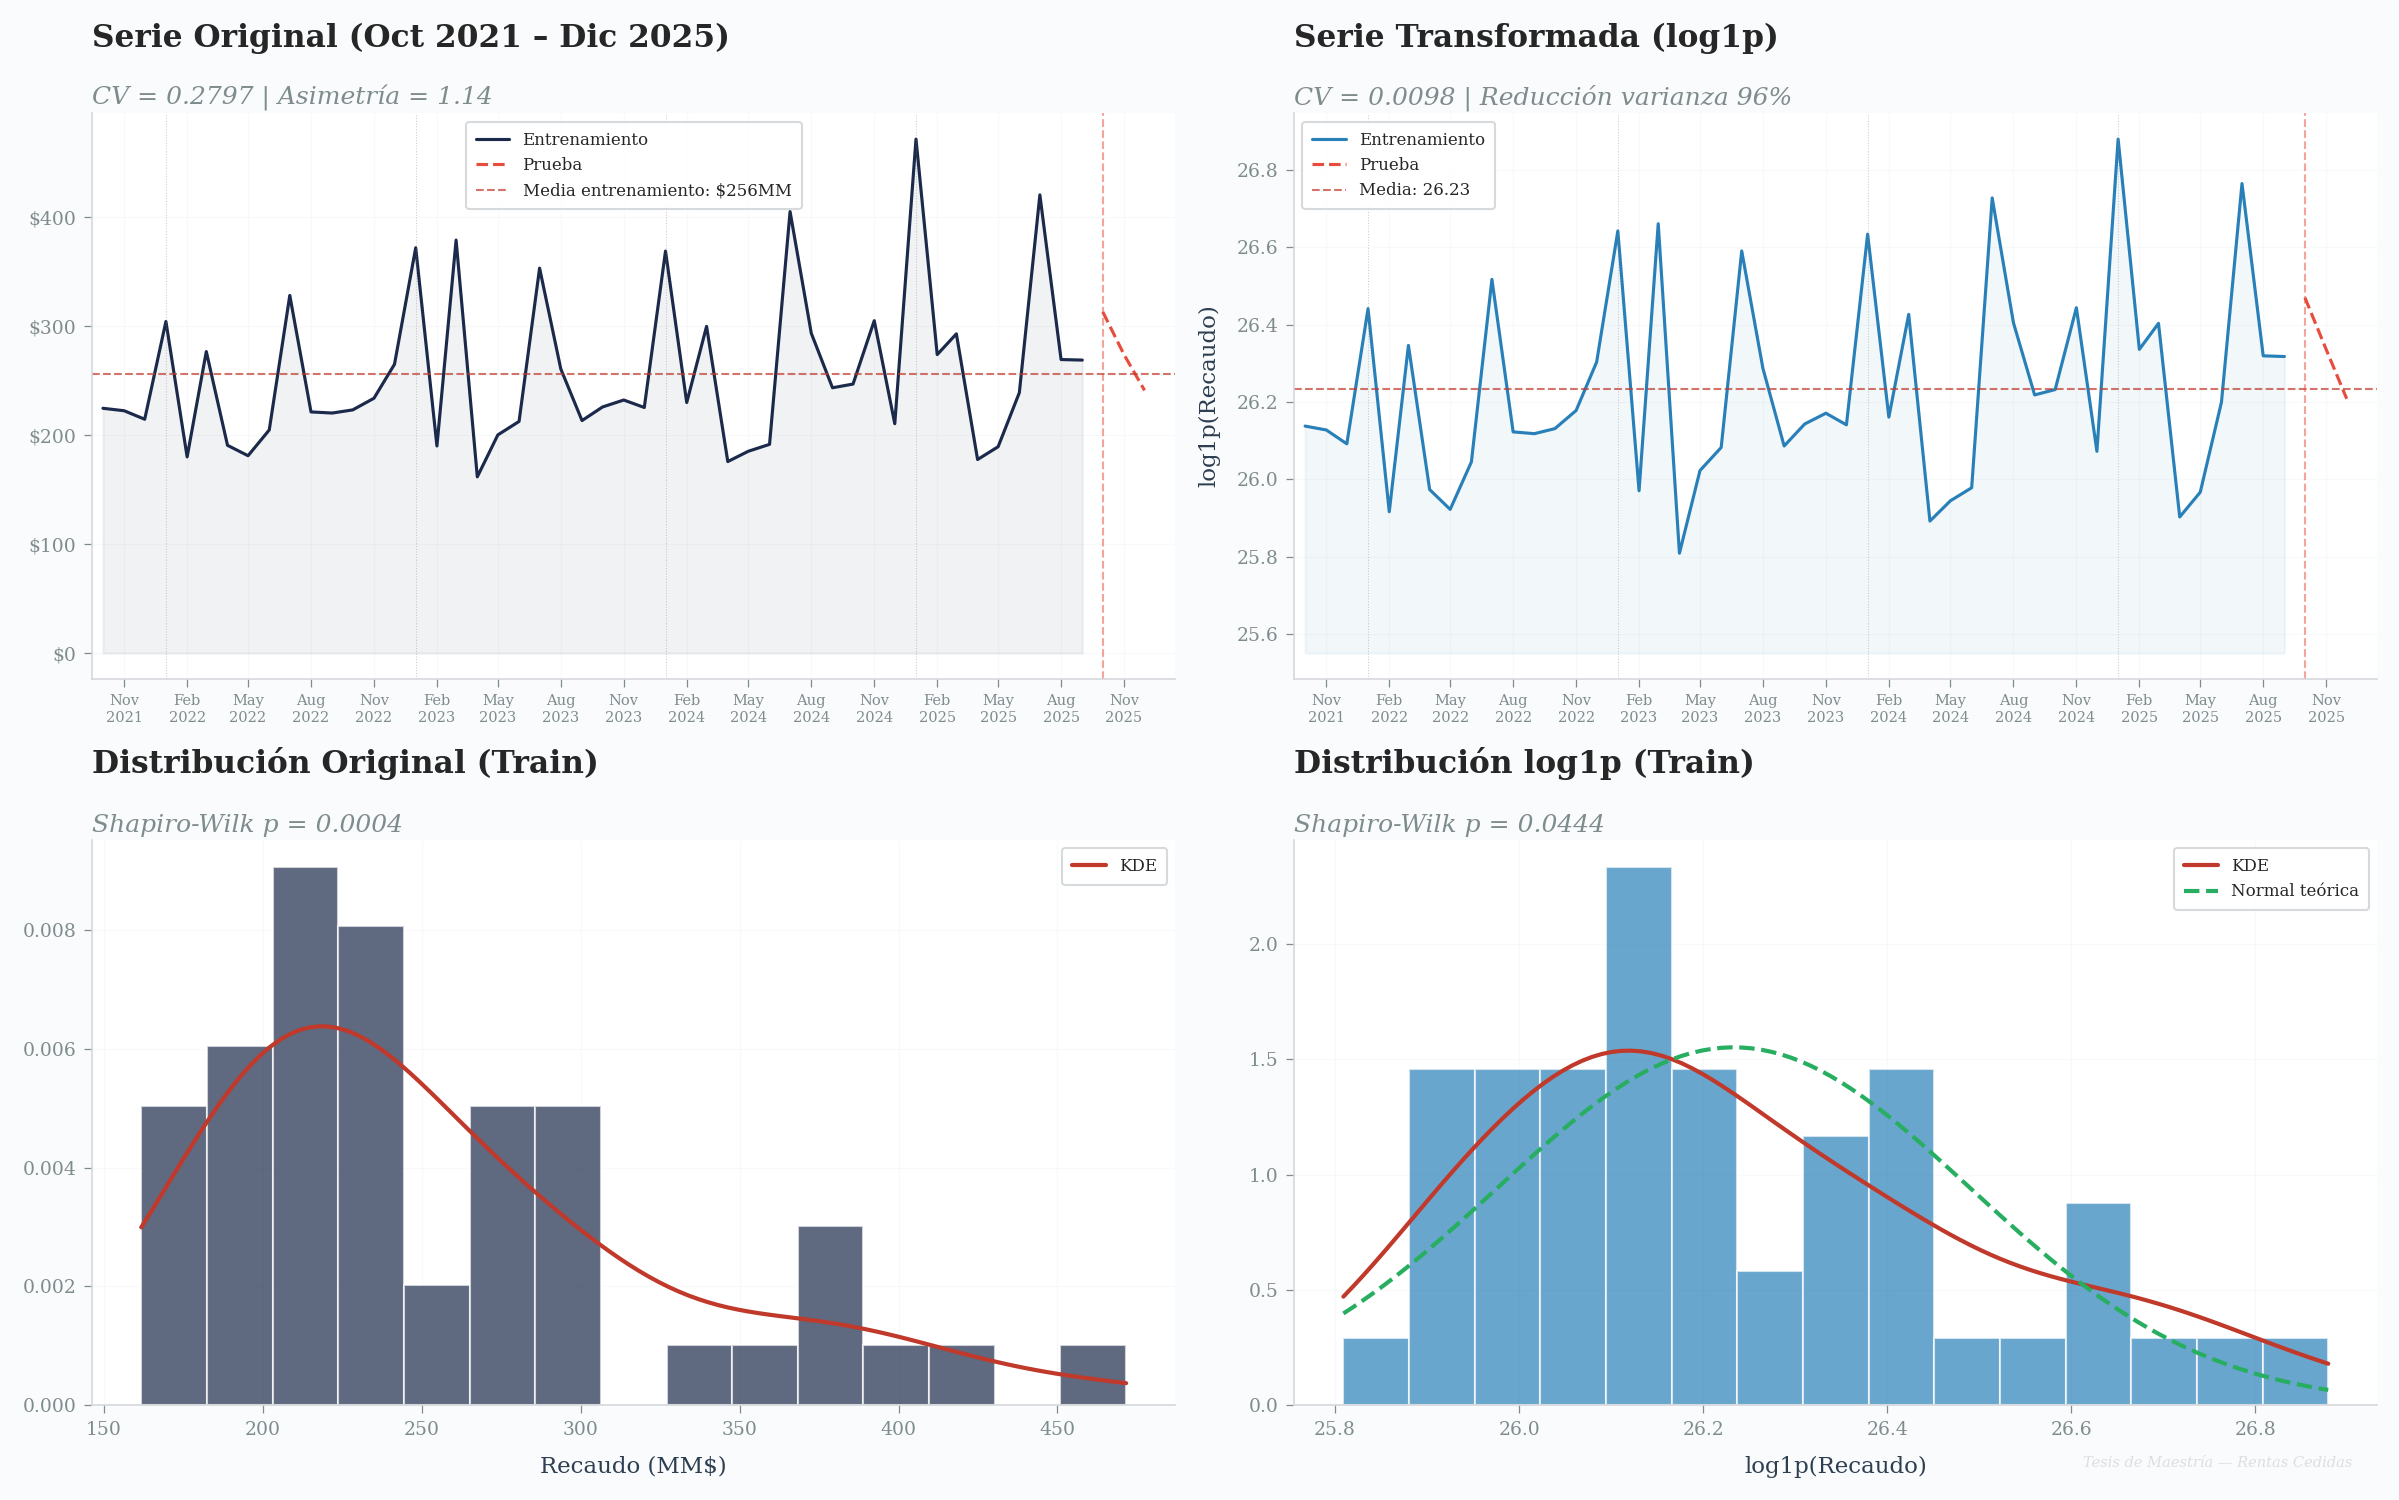


  → Transformación log1p seleccionada para modelado SARIMA
  → La serie transformada se usará en todas las fases siguientes


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE I-b — Estabilización de Varianza (log1p) y Visualización
# ══════════════════════════════════════════════════════════════

# ── Transformación log1p (sobre train) ──
train_log = np.log1p(train)
test_log  = np.log1p(test)
serie_log = np.log1p(serie_full)  # referencia completa

cv_orig = train.std() / train.mean()
cv_log  = train_log.std() / train_log.mean()

print(f"{'═'*70}")
print(f"ESTABILIZACIÓN DE VARIANZA — Transformación log1p")
print(f"{'═'*70}")
print(f"  CV original: {cv_orig:.4f}")
print(f"  CV log1p:    {cv_log:.4f}")
print(f"  Reducción:   {(1 - cv_log/cv_orig)*100:.1f}%")
print(f"  Asimetría original: {stats.skew(train.values):.4f}")
print(f"  Asimetría log1p:    {stats.skew(train_log.values):.4f}")

# ── Visualización (2×2) ──
xlim_ini = pd.Timestamp('2021-09-15')
xlim_fin = pd.Timestamp('2026-01-15')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Serie original (train + test)
ax = axes[0, 0]
ax.plot(train.index, train.values/1e9, color=C_PRIMARY, lw=1.5, label='Entrenamiento')
ax.plot(test.index, test.values/1e9, color=C_TEST, lw=1.5, ls='--', label='Prueba')
ax.fill_between(train.index, 0, train.values/1e9, alpha=0.06, color=C_PRIMARY)
ax.axhline(train.mean()/1e9, color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
           label=f'Media entrenamiento: ${train.mean()/1e9:.0f}MM')
ax.axvline(pd.Timestamp('2025-10-01'), color=C_TEST, ls='--', lw=1, alpha=0.5)
ax.set_xlim(xlim_ini, xlim_fin)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Original (Oct 2021 – Dic 2025)', f'CV = {cv_orig:.4f} | Asimetría = {stats.skew(train.values):.2f}')
    formato_pesos_eje(ax, eje='y')

# Panel 2: Serie log1p
ax = axes[0, 1]
ax.plot(train_log.index, train_log.values, color=C_TERTIARY, lw=1.5, label='Entrenamiento')
ax.plot(test_log.index, test_log.values, color=C_TEST, lw=1.5, ls='--', label='Prueba')
ax.fill_between(train_log.index, train_log.min()*0.99, train_log.values,
                alpha=0.06, color=C_TERTIARY)
ax.axhline(train_log.mean(), color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
           label=f'Media: {train_log.mean():.2f}')
ax.axvline(pd.Timestamp('2025-10-01'), color=C_TEST, ls='--', lw=1, alpha=0.5)
ax.set_xlim(xlim_ini, xlim_fin)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
ax.set_ylabel('log1p(Recaudo)', fontdict=FONT_AXIS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Transformada (log1p)',
                       f'CV = {cv_log:.4f} | Reducción varianza {(1-cv_log/cv_orig)*100:.0f}%')

# Panel 3: Histograma original (train)
ax = axes[1, 0]
ax.hist(train.values/1e9, bins=15, color=C_PRIMARY, edgecolor='white',
        alpha=0.7, density=True)
x_kde = np.linspace(train.min()/1e9, train.max()/1e9, 100)
kde_orig = stats.gaussian_kde(train.values/1e9)
ax.plot(x_kde, kde_orig(x_kde), color=C_SECONDARY, lw=2, label='KDE')
ax.set_xlabel('Recaudo (MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución Original (Train)',
                       f'Shapiro-Wilk p = {stats.shapiro(train.values)[1]:.4f}')

# Panel 4: Histograma log1p (train)
ax = axes[1, 1]
ax.hist(train_log.values, bins=15, color=C_TERTIARY, edgecolor='white',
        alpha=0.7, density=True)
x_kde_l = np.linspace(train_log.min(), train_log.max(), 100)
kde_log = stats.gaussian_kde(train_log.values)
ax.plot(x_kde_l, kde_log(x_kde_l), color=C_SECONDARY, lw=2, label='KDE')
# Normal teórica
ax.plot(x_kde_l, stats.norm.pdf(x_kde_l, train_log.mean(), train_log.std()),
        color=C_QUATERNARY, lw=2, ls='--', label='Normal teórica')
ax.set_xlabel('log1p(Recaudo)', fontdict=FONT_AXIS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución log1p (Train)',
                       f'Shapiro-Wilk p = {stats.shapiro(train_log.values)[1]:.4f}')

# Separadores de año
for row in axes:
    for a in row:
        if hasattr(a, 'get_xlim') and a.get_xlim()[1] > 1e3:
            for y_sep in range(2022, 2026):
                a.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey',
                          ls=':', lw=0.5, alpha=0.4)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_estabilizacion_varianza', OUTPUTS_FIGURES)
plt.show()

print(f"\n  → Transformación log1p seleccionada para modelado SARIMA")
print(f"  → La serie transformada se usará en todas las fases siguientes")

---

## Fase II — Análisis de Estacionariedad

### Marco Teórico

Un modelo SARIMA$(p,d,q)(P,D,Q)_s$ requiere que la serie sea estacionaria
después de las diferenciaciones $d$ (regular) y $D$ (estacional).

Se aplican dos pruebas complementarias (principio de robustez):

| Prueba | $H_0$ | $H_1$ | Criterio |
|--------|--------|--------|----------|
| **ADF** (Dickey-Fuller Aumentada) | Raíz unitaria (no estacionaria) | Estacionaria | Rechazar $H_0$ si $p < 0.05$ |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | Estacionaria | No estacionaria | Rechazar $H_0$ si $p < 0.05$ |

**Diferenciación estacional:** La fuerte estacionalidad reproducible identificada
en NB 02 ($F_s = 0.90$, patrón "electrocardiograma") exige una diferencia
estacional $D = 1$ con $s = 12$ para estabilizar la media interanual.

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE II-a — Pruebas ADF + KPSS (serie log1p)
# ══════════════════════════════════════════════════════════════

def test_estacionariedad(serie_test, nombre):
    # Ejecuta ADF + KPSS y retorna diccionario de resultados.
    # ADF
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(serie_test, autolag='AIC')
    # KPSS (trend='c' para nivel)
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie_test, regression='c', nlags='auto')

    estacionaria_adf  = adf_p < 0.05
    estacionaria_kpss = kpss_p > 0.05  # No rechazar H0 = estacionaria

    return {
        'nombre': nombre,
        'adf_stat': adf_stat, 'adf_p': adf_p,
        'kpss_stat': kpss_stat, 'kpss_p': kpss_p,
        'estac_adf': estacionaria_adf,
        'estac_kpss': estacionaria_kpss,
        'conclusion': 'ESTACIONARIA' if (estacionaria_adf and estacionaria_kpss) else 'NO ESTACIONARIA',
    }

# ── Variantes de diferenciación ──
y = train_log.copy()  # Serie log1p train (Oct 2021 – Sep 2025)

# (a) Original (log1p)
r0 = test_estacionariedad(y, 'log1p(y)')

# (b) Diferencia regular d=1
y_d1 = y.diff().dropna()
r1 = test_estacionariedad(y_d1, 'Δy (d=1)')

# (c) Diferencia estacional D=1, s=12
y_D1 = y.diff(12).dropna()
r2 = test_estacionariedad(y_D1, 'Δ₁₂y (D=1)')

# (d) Doble diferenciación d=1 + D=1
y_dD = y.diff(12).diff().dropna()
r3 = test_estacionariedad(y_dD, 'ΔΔ₁₂y (d=1, D=1)')

# ── Reporte ──
results_list = [r0, r1, r2, r3]
print(f"{'═'*78}")
print(f"PRUEBAS DE ESTACIONARIEDAD — Serie log1p train (Oct 2021 – Sep 2025, n={len(y)})")
print(f"{'═'*78}")
print(f"{'Transformación':<20} {'ADF stat':>10} {'ADF p':>8} {'KPSS stat':>10} {'KPSS p':>8} {'Conclusión':>18}")
print(f"{'─'*78}")
for r in results_list:
    ic_adf  = '✅' if r['estac_adf']  else '❌'
    ic_kpss = '✅' if r['estac_kpss'] else '❌'
    print(f"  {r['nombre']:<18} {r['adf_stat']:>10.4f} {r['adf_p']:>7.4f}{ic_adf} "
          f"{r['kpss_stat']:>9.4f} {r['kpss_p']:>7.2f}{ic_kpss}  {r['conclusion']}")

print(f"\n{'─'*78}")
print(f"DECISIÓN DE DIFERENCIACIÓN:")
if r3['conclusion'] == 'ESTACIONARIA':
    print(f"  → d = 1, D = 1 con s = 12: serie estacionaria confirmada por ADF + KPSS")
elif r1['conclusion'] == 'ESTACIONARIA':
    print(f"  → d = 1 suficiente (sin diferencia estacional)")
else:
    print(f"  → Requiere evaluación adicional")

d_opt = 1
D_opt = 1
print(f"\n  Parámetros seleccionados: d = {d_opt}, D = {D_opt}, s = {ESTACIONALIDAD}")

══════════════════════════════════════════════════════════════════════════════
PRUEBAS DE ESTACIONARIEDAD — Serie log1p train (Oct 2021 – Sep 2025, n=48)
══════════════════════════════════════════════════════════════════════════════
Transformación         ADF stat    ADF p  KPSS stat   KPSS p         Conclusión
──────────────────────────────────────────────────────────────────────────────
  log1p(y)              -1.9872  0.2922❌    0.2644    0.10✅  NO ESTACIONARIA
  Δy (d=1)              -7.1264  0.0000✅    0.0213    0.10✅  ESTACIONARIA
  Δ₁₂y (D=1)            -6.8038  0.0000✅    0.1018    0.10✅  ESTACIONARIA
  ΔΔ₁₂y (d=1, D=1)      -8.6140  0.0000✅    0.3268    0.10✅  ESTACIONARIA

──────────────────────────────────────────────────────────────────────────────
DECISIÓN DE DIFERENCIACIÓN:
  → d = 1, D = 1 con s = 12: serie estacionaria confirmada por ADF + KPSS

  Parámetros seleccionados: d = 1, D = 1, s = 12


C:\Users\efren\AppData\Local\Temp\ipykernel_107784\3975408724.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie_test, regression='c', nlags='auto')
C:\Users\efren\AppData\Local\Temp\ipykernel_107784\3975408724.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie_test, regression='c', nlags='auto')
C:\Users\efren\AppData\Local\Temp\ipykernel_107784\3975408724.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie_test, regression='c', nlags='auto')
C:\Users\efren\AppD

  📊 Figura guardada: 04_estacionariedad_tests.png


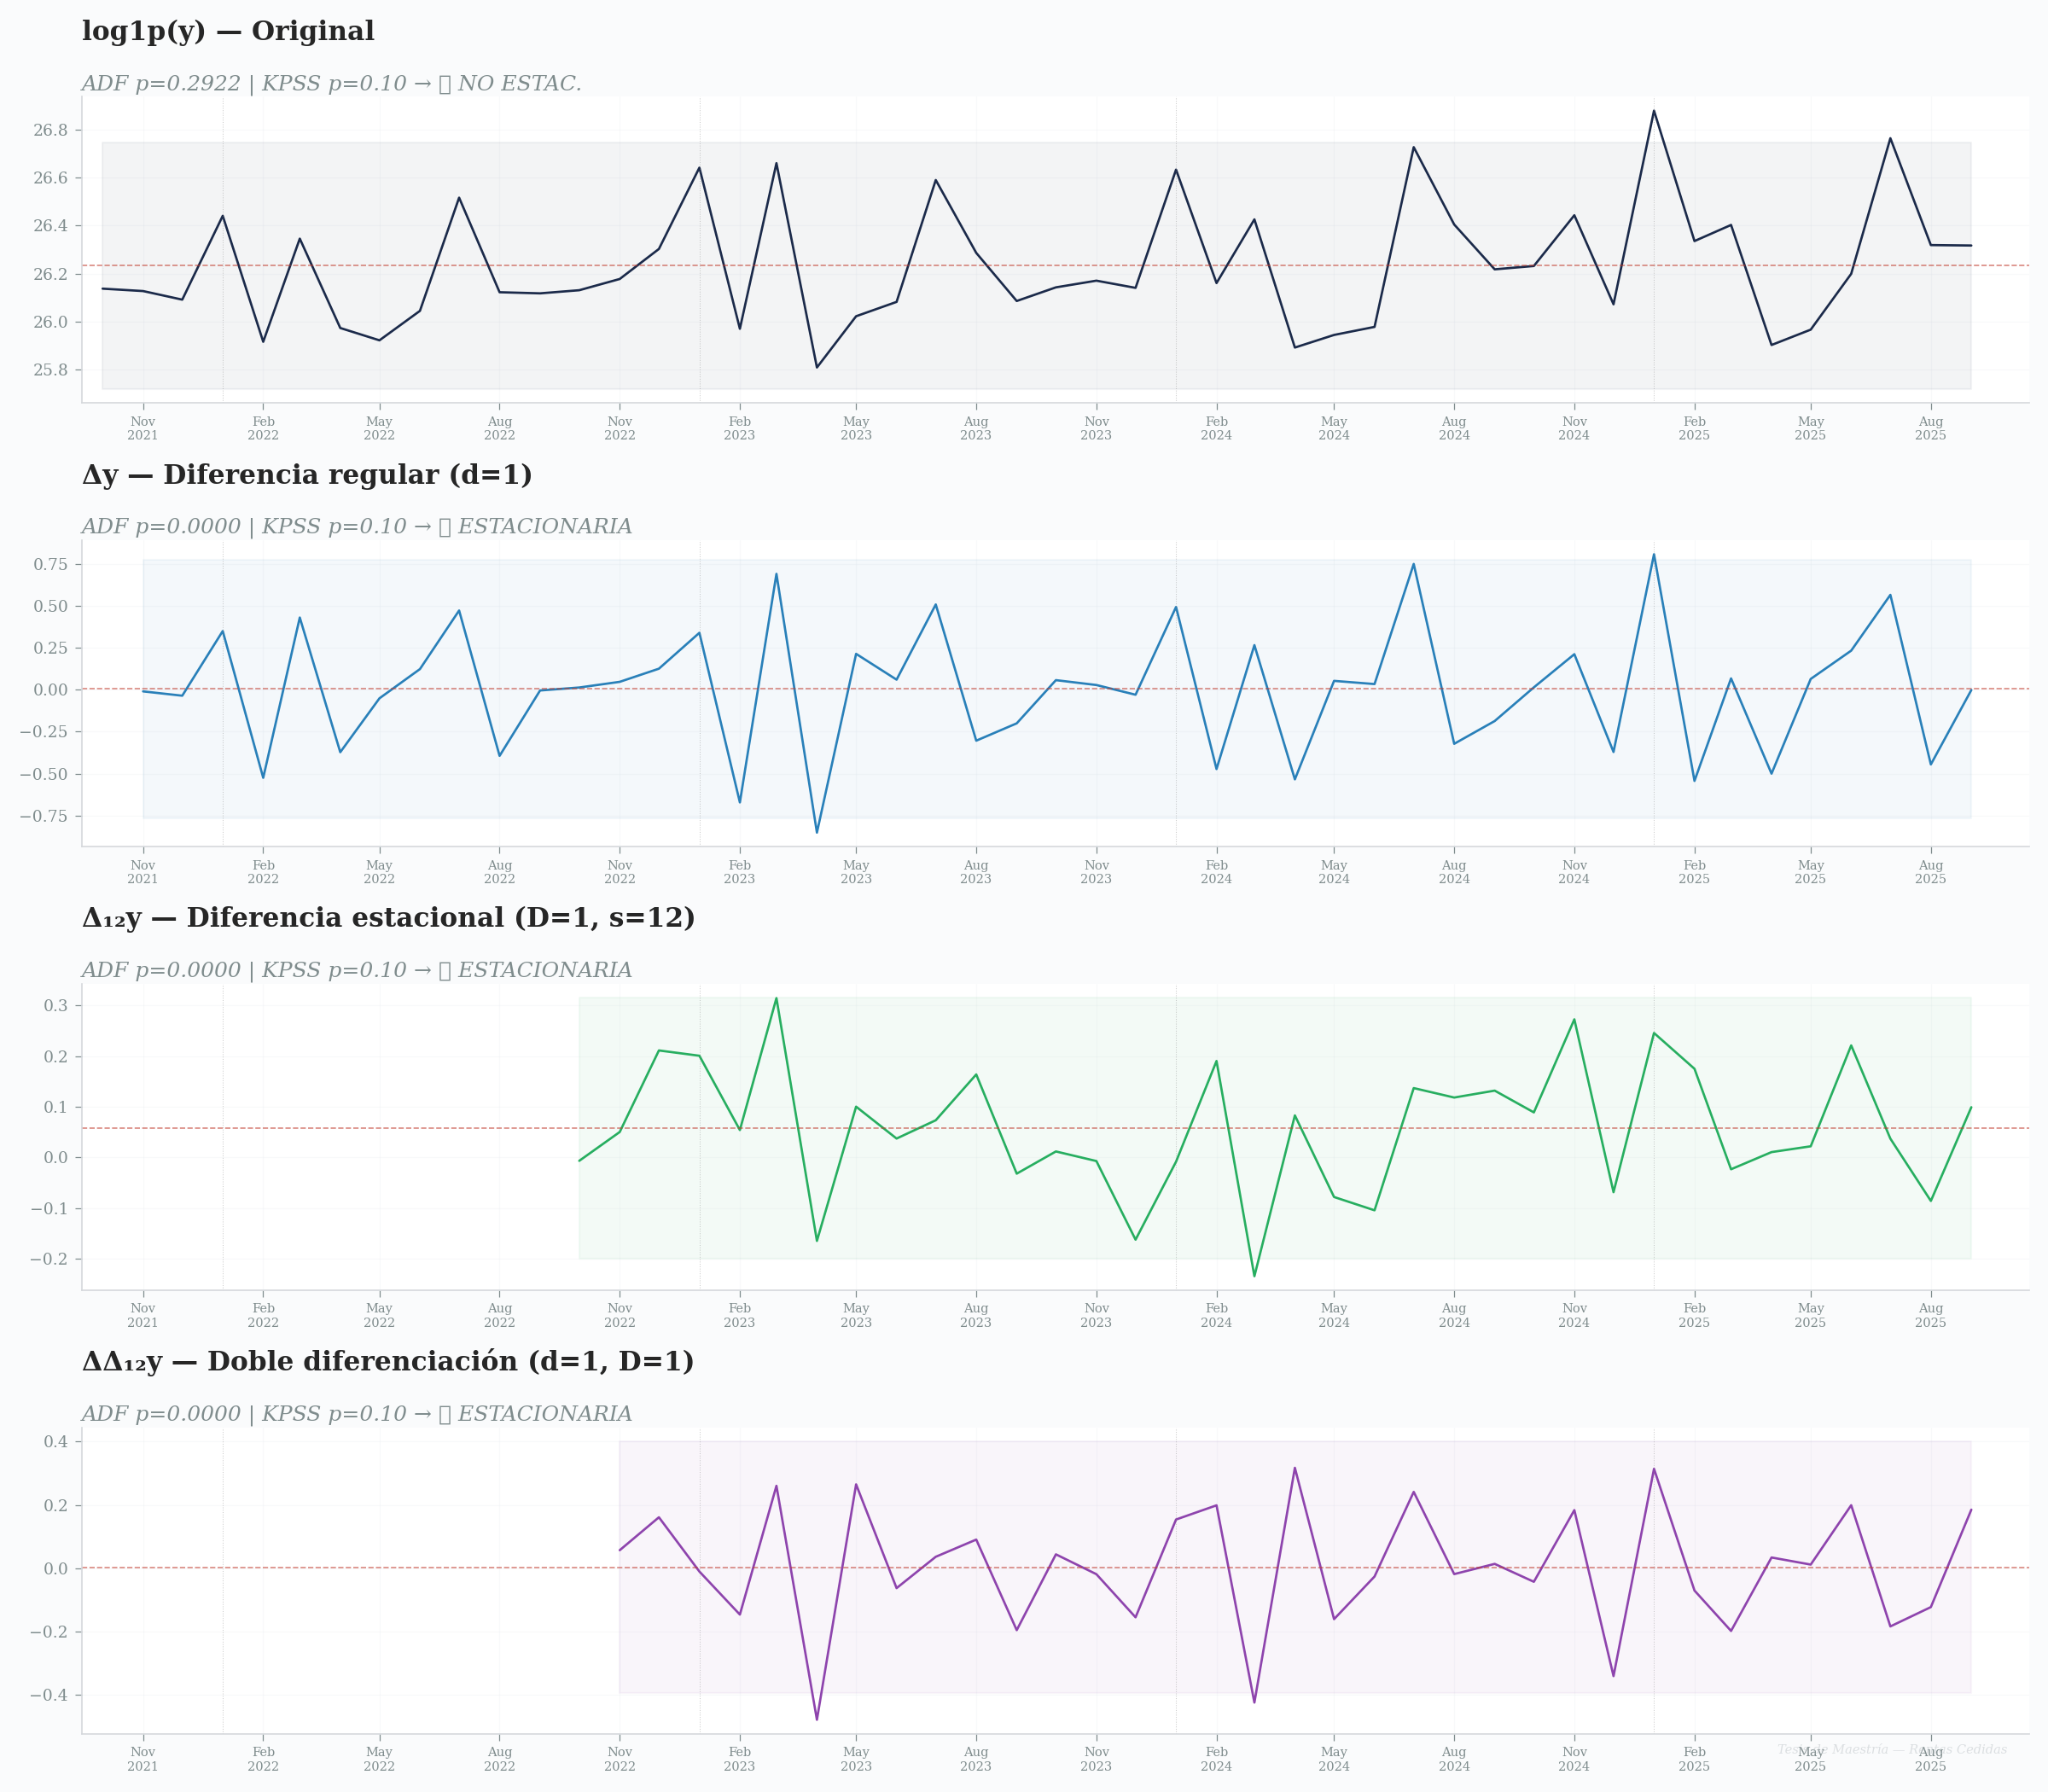

  → 4 niveles de diferenciación evaluados
  → Selección: d=1, D=1 (doble diferenciación)


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE II-b — Visualización de Transformaciones de Diferenciación
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)

series_diff = [
    (y,    'log1p(y) — Original',     C_PRIMARY,    r0),
    (y_d1, 'Δy — Diferencia regular (d=1)', C_TERTIARY, r1),
    (y_D1, 'Δ₁₂y — Diferencia estacional (D=1, s=12)', C_QUATERNARY, r2),
    (y_dD, 'ΔΔ₁₂y — Doble diferenciación (d=1, D=1)', C_SENARY, r3),
]

xlim_ini_d = pd.Timestamp('2021-09-15')
xlim_fin_d = pd.Timestamp('2025-10-15')

for idx, (s, titulo, color, res) in enumerate(series_diff):
    ax = axes[idx]
    ax.plot(s.index, s.values, color=color, lw=1.3)
    ax.axhline(s.mean(), color=C_SECONDARY, ls='--', lw=0.8, alpha=0.6)
    ax.fill_between(s.index, s.mean() - 2*s.std(), s.mean() + 2*s.std(),
                    alpha=0.05, color=color)
    ax.grid(True, alpha=0.3)

    # Configurar eje temporal
    if len(s) > 10:
        ax.set_xlim(xlim_ini_d, xlim_fin_d)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        ax.tick_params(axis='x', labelsize=7)
        for y_sep in range(2022, 2026):
            ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey',
                       ls=':', lw=0.5, alpha=0.4)

    # Subtítulo con resultado del test
    badge = '✅ ESTACIONARIA' if res['conclusion'] == 'ESTACIONARIA' else '❌ NO ESTAC.'
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, titulo,
                           f"ADF p={res['adf_p']:.4f} | KPSS p={res['kpss_p']:.2f} → {badge}")
    else:
        ax.set_title(f"{titulo}\nADF p={res['adf_p']:.4f} | KPSS p={res['kpss_p']:.2f} → {badge}",
                     fontsize=11, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_estacionariedad_tests', OUTPUTS_FIGURES)
plt.show()

print(f"  → 4 niveles de diferenciación evaluados")
print(f"  → Selección: d={d_opt}, D={D_opt} (doble diferenciación)")

---

## Fase III — Identificación de Parámetros (ACF / PACF)

### Interpretación de los Correlogramas

Los gráficos de autocorrelación permiten identificar los órdenes $(p, q)$ del
componente ARIMA no estacional y $(P, Q)$ del componente estacional:

| Rezago | Componente | Patrón ACF | Patrón PACF |
|--------|------------|------------|-------------|
| **1–3** | ARIMA (p, q) | Decaimiento → MA(q) | Corte abrupto → AR(p) |
| **12, 24** | Estacional (P, Q) | Pico en lag 12 → SMA(Q) | Pico en lag 12 → SAR(P) |

### Hipótesis del Rezago Contable

El consumo masivo de **diciembre** (temporada navideña, licores, juegos de azar)
se materializa en el **recaudo de enero** del año siguiente, generando un rezago
contable de 1 mes que debe reflejarse como autocorrelación significativa en lag 1
y como estacionalidad reforzada en lags 12 y 24.

  📊 Figura guardada: 04_acf_pacf.png


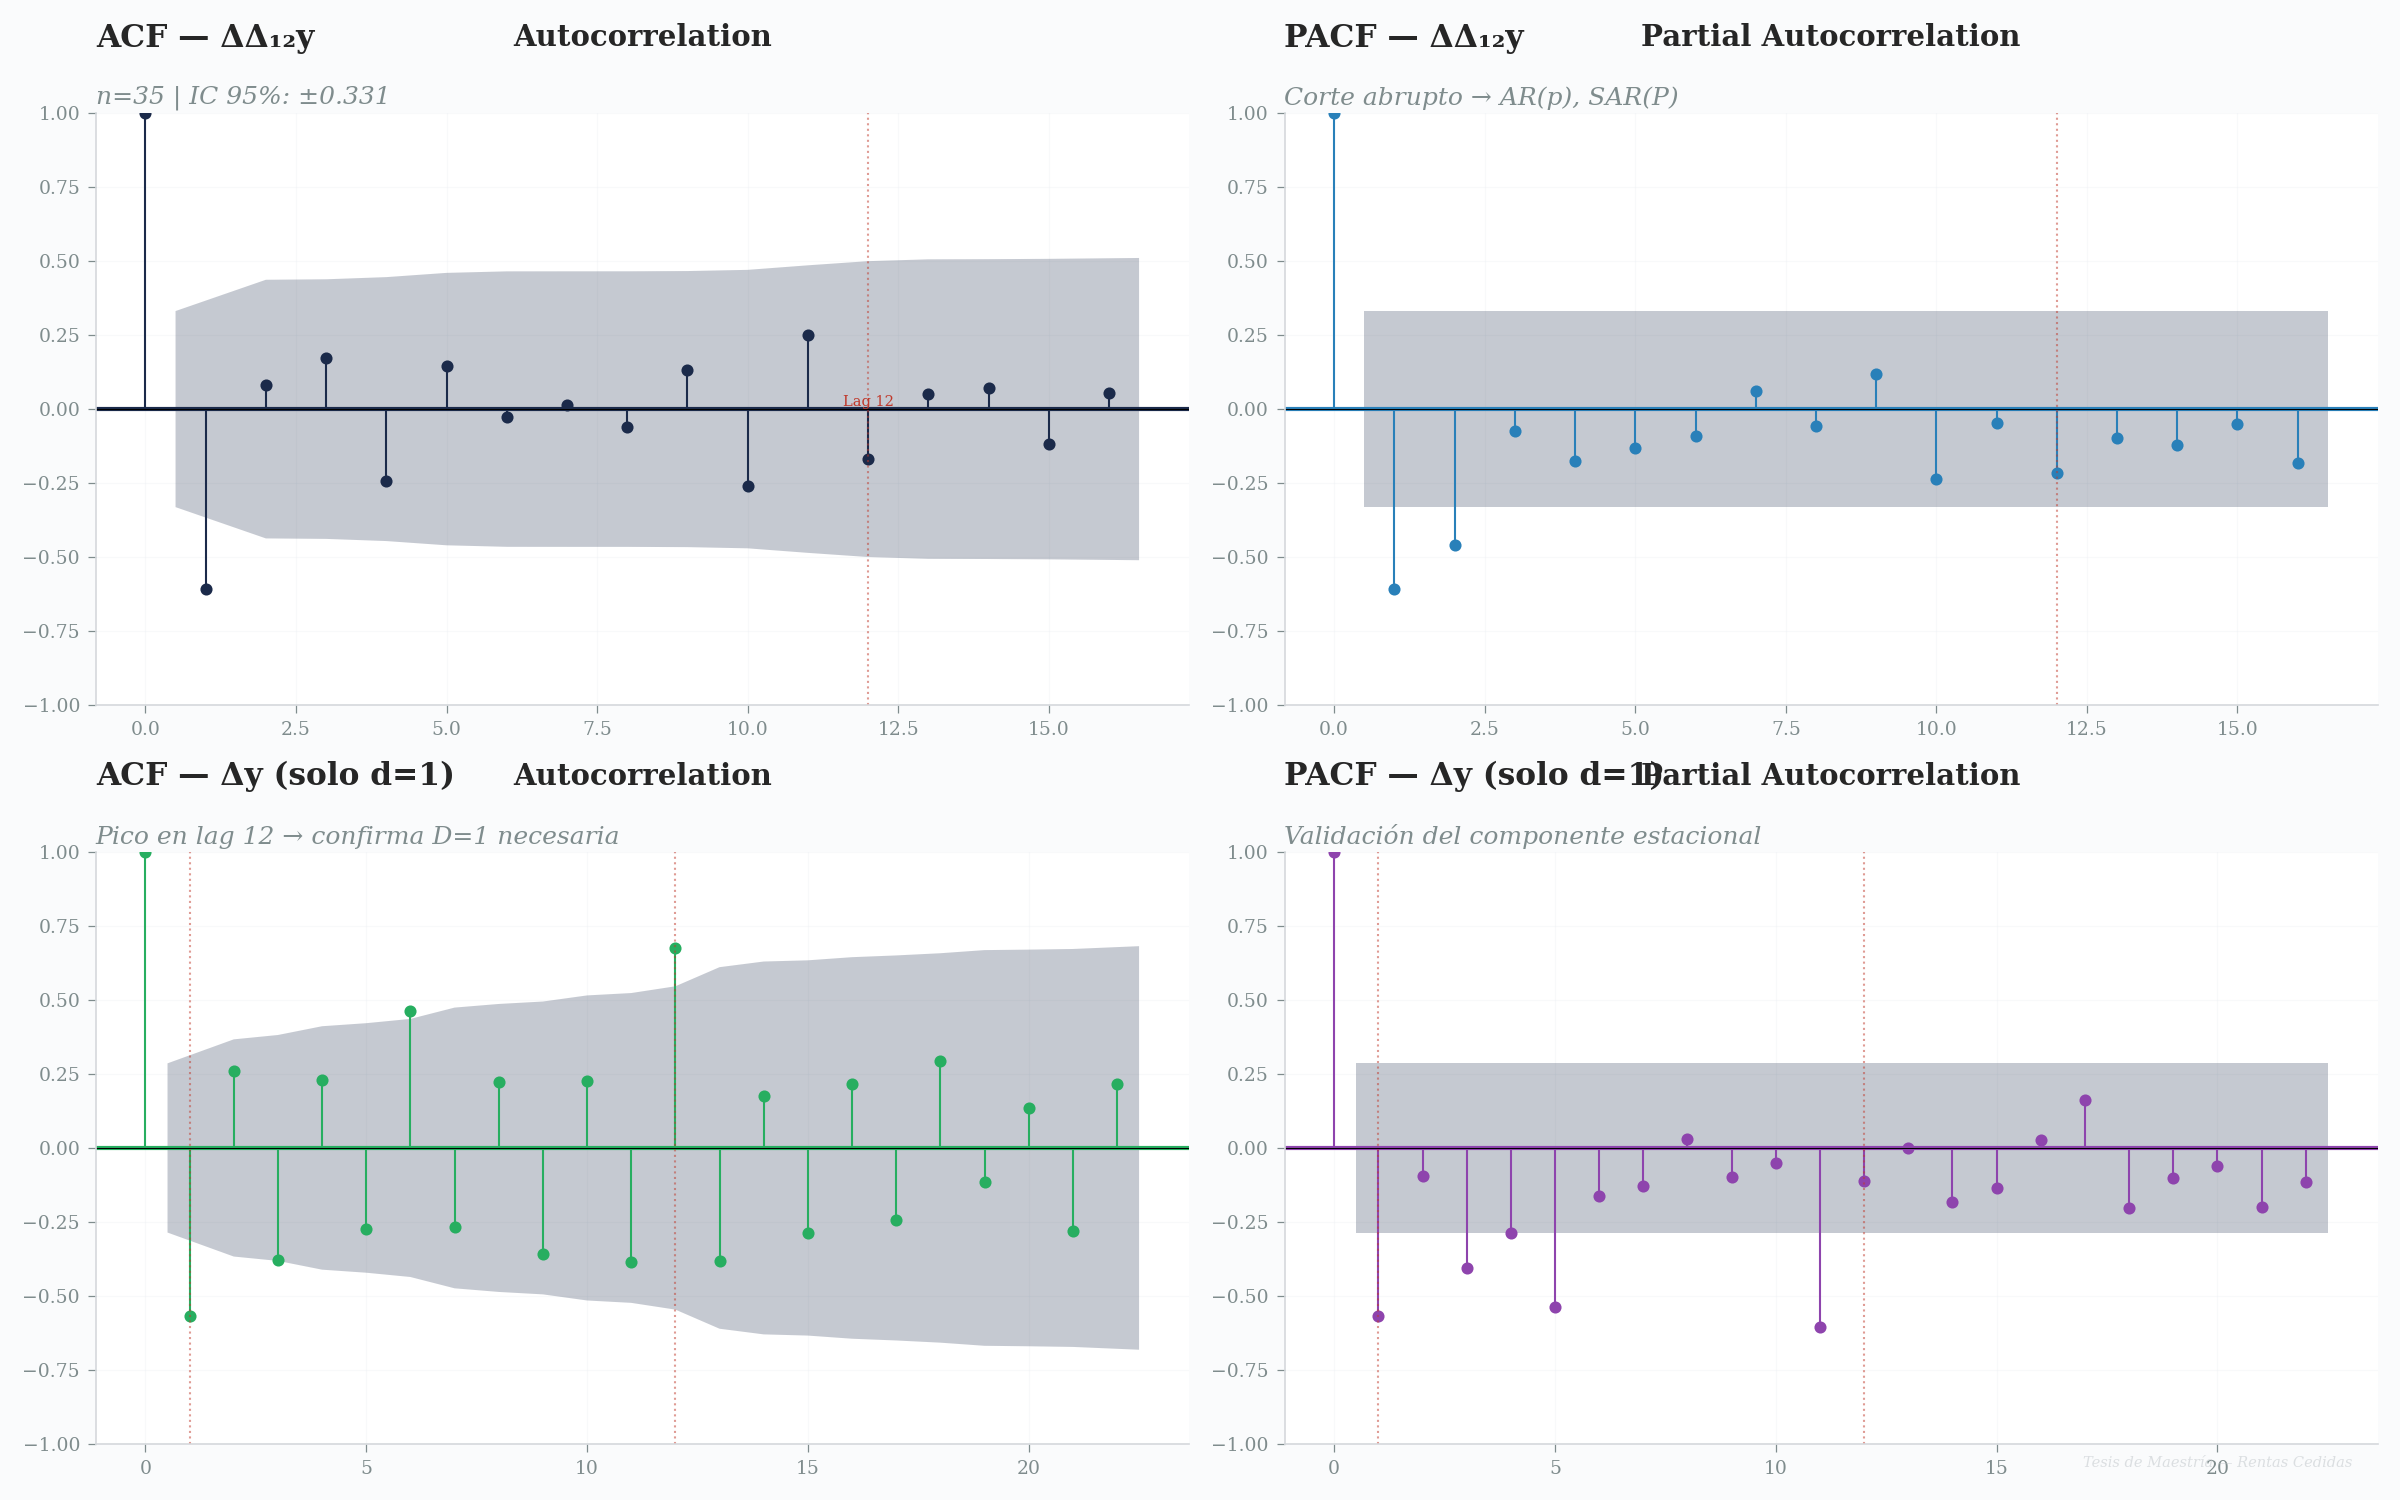


══════════════════════════════════════════════════════════════════════
INTERPRETACIÓN DE CORRELOGRAMAS
══════════════════════════════════════════════════════════════════════
  Lags significativos ACF:  [1]
  Lags significativos PACF: [1, 2]

  Sugerencia de órdenes (heurística ACF/PACF):
    p ≤ 2 (PACF corta en lags cortos)
    q ≤ 1 (ACF corta en lags cortos)
    P ≤ 0 (componente estacional AR)
    Q ≤ 0 (componente estacional MA)
    d = 1, D = 1, s = 12

──────────────────────────────────────────────────────────────────────
HIPÓTESIS DEL REZAGO CONTABLE (Dic → Ene):
  ACF en lag 1: -0.6083 (significativo)
  → Confirma rezago contable: consumo Dic se refleja en recaudo Ene


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE III — Correlogramas ACF / PACF
# ══════════════════════════════════════════════════════════════

# Serie doblemente diferenciada (la que alimentará el SARIMA)
y_modelo = y_dD.copy()
n_modelo = len(y_modelo)
n_lags = min(24, n_modelo // 2 - 1)
n_lags_s = min(n_lags, 24)  # incluir lag 24 si es posible

# ── Calcular ACF y PACF manualmente para interpretación ──
acf_vals  = acf(y_modelo, nlags=n_lags, alpha=0.05)
pacf_vals = pacf(y_modelo, nlags=n_lags, method='ywm', alpha=0.05)

ci_95 = 1.96 / np.sqrt(n_modelo)

# ── Gráfica 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: ACF de la serie doblemente diferenciada
ax = axes[0, 0]
plot_acf(y_modelo, ax=ax, lags=n_lags, alpha=0.05,
         color=C_PRIMARY, vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1.0})
ax.axhline(y=0, color='black', lw=0.5)
# Resaltar lags estacionales
for lag_s in [12, 24]:
    if lag_s <= n_lags:
        ax.axvline(x=lag_s, color=C_SECONDARY, ls=':', lw=1, alpha=0.5)
        ax.annotate(f'Lag {lag_s}', xy=(lag_s, 0), fontsize=7,
                    color=C_SECONDARY, ha='center', va='bottom')
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'ACF — ΔΔ₁₂y', f'n={n_modelo} | IC 95%: ±{ci_95:.3f}')

# Panel 2: PACF de la serie doblemente diferenciada
ax = axes[0, 1]
plot_pacf(y_modelo, ax=ax, lags=n_lags, alpha=0.05, method='ywm',
          color=C_TERTIARY, vlines_kwargs={'colors': C_TERTIARY, 'linewidth': 1.0})
ax.axhline(y=0, color='black', lw=0.5)
for lag_s in [12, 24]:
    if lag_s <= n_lags:
        ax.axvline(x=lag_s, color=C_SECONDARY, ls=':', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'PACF — ΔΔ₁₂y', 'Corte abrupto → AR(p), SAR(P)')

# Panel 3: ACF de la serie con solo d=1 (para ver lag 12)
ax = axes[1, 0]
n_lags_d1 = min(24, len(y_d1) // 2 - 1)
plot_acf(y_d1, ax=ax, lags=n_lags_d1, alpha=0.05,
         color=C_QUATERNARY, vlines_kwargs={'colors': C_QUATERNARY, 'linewidth': 1.0})
ax.axhline(y=0, color='black', lw=0.5)
for lag_s in [1, 12, 24]:
    if lag_s <= n_lags_d1:
        ax.axvline(x=lag_s, color=C_SECONDARY, ls=':', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'ACF — Δy (solo d=1)',
                       'Pico en lag 12 → confirma D=1 necesaria')

# Panel 4: PACF de la serie con solo d=1
ax = axes[1, 1]
plot_pacf(y_d1, ax=ax, lags=n_lags_d1, alpha=0.05, method='ywm',
          color=C_SENARY, vlines_kwargs={'colors': C_SENARY, 'linewidth': 1.0})
ax.axhline(y=0, color='black', lw=0.5)
for lag_s in [1, 12]:
    if lag_s <= n_lags_d1:
        ax.axvline(x=lag_s, color=C_SECONDARY, ls=':', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'PACF — Δy (solo d=1)',
                       'Validación del componente estacional')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_acf_pacf', OUTPUTS_FIGURES)
plt.show()

# ── Interpretación automática ──
print(f"\n{'═'*70}")
print(f"INTERPRETACIÓN DE CORRELOGRAMAS")
print(f"{'═'*70}")

# Identificar lags significativos en ACF y PACF
acf_sig  = [i for i in range(1, n_lags+1) if abs(acf_vals[0][i]) > ci_95]
pacf_sig = [i for i in range(1, n_lags+1) if abs(pacf_vals[0][i]) > ci_95]

print(f"  Lags significativos ACF:  {acf_sig if acf_sig else 'Ninguno (ruido blanco)'}")
print(f"  Lags significativos PACF: {pacf_sig if pacf_sig else 'Ninguno (ruido blanco)'}")

# Sugerencias de órdenes
p_sug = min(len([l for l in pacf_sig if l <= 3]), 2)
q_sug = min(len([l for l in acf_sig  if l <= 3]), 2)
P_sug = 1 if 12 in pacf_sig or 12 in acf_sig else 0
Q_sug = 1 if 12 in acf_sig else 0

print(f"\n  Sugerencia de órdenes (heurística ACF/PACF):")
print(f"    p ≤ {p_sug} (PACF corta en lags cortos)")
print(f"    q ≤ {q_sug} (ACF corta en lags cortos)")
print(f"    P ≤ {P_sug} (componente estacional AR)")
print(f"    Q ≤ {Q_sug} (componente estacional MA)")
print(f"    d = {d_opt}, D = {D_opt}, s = {ESTACIONALIDAD}")

# Hipótesis del rezago Dic→Ene
lag1_acf = acf_vals[0][1] if len(acf_vals[0]) > 1 else 0
print(f"\n{'─'*70}")
print(f"HIPÓTESIS DEL REZAGO CONTABLE (Dic → Ene):")
print(f"  ACF en lag 1: {lag1_acf:.4f} ({'significativo' if abs(lag1_acf) > ci_95 else 'NO significativo'})")
if abs(lag1_acf) > ci_95:
    print(f"  → Confirma rezago contable: consumo Dic se refleja en recaudo Ene")
else:
    print(f"  → Rezago contable NO significativo en la serie diferenciada")
    print(f"    (puede estar absorbido por la diferenciación estacional)")

---

## Fase IV — Búsqueda en Rejilla (Grid Search AICc)

### Criterio de Selección: AICc

El criterio de Akaike corregido (AICc) penaliza la complejidad del modelo más
severamente que AIC cuando la muestra es pequeña ($n = 48$):

$$
\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n - k - 1}
$$

donde $k$ es el número de parámetros y $n$ el tamaño efectivo de la muestra.

### Espacio de Búsqueda

| Parámetro | Rango | Justificación |
|-----------|-------|---------------|
| $p$ | {0, 1, 2} | PACF sugiere ≤ 2 lags AR significativos |
| $d$ | {1} | ADF confirma necesidad de 1 diferencia regular |
| $q$ | {0, 1, 2} | ACF sugiere ≤ 2 lags MA significativos |
| $P$ | {0, 1} | 1 ciclo estacional AR como máximo (n limitado) |
| $D$ | {1} | Estacionalidad fuerte exige 1 diferencia estacional |
| $Q$ | {0, 1} | 1 ciclo estacional MA como máximo |
| $s$ | 12 | Frecuencia mensual (ciclo anual) |

**Total:** $3 \times 1 \times 3 \times 2 \times 1 \times 2 = 36$ combinaciones.

In [7]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Grid Search AICc sobre serie log1p (train)
# ══════════════════════════════════════════════════════════════
import time

# ── Espacio de búsqueda ──
p_range = range(0, 3)   # 0, 1, 2
d_fixed = 1
q_range = range(0, 3)   # 0, 1, 2
P_range = range(0, 2)   # 0, 1
D_fixed = 1
Q_range = range(0, 2)   # 0, 1
s_fixed = ESTACIONALIDAD  # 12

grid = list(product(p_range, q_range, P_range, Q_range))
n_total = len(grid)

print(f"{'═'*70}")
print(f"GRID SEARCH — SARIMA(p,{d_fixed},q)(P,{D_fixed},Q,{s_fixed})")
print(f"{'═'*70}")
print(f"  Combinaciones a evaluar: {n_total}")
print(f"  Serie: log_entrenamiento ({len(train_log)} obs)")
print(f"  Criterio de selección: AICc\n")

# ── Función AICc ──
def calc_aicc(aic, k, n):
    # AICc = AIC + 2k(k+1)/(n-k-1)
    if n - k - 1 <= 0:
        return np.inf
    return aic + 2 * k * (k + 1) / (n - k - 1)

# ── Grid Search ──
resultados = []
t0 = time.time()
n_fallidos = 0

for i, (p, q, P, Q) in enumerate(grid):
    order = (p, d_fixed, q)
    seasonal = (P, D_fixed, Q, s_fixed)
    try:
        mod = SARIMAX(train_log, order=order, seasonal_order=seasonal,
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False, maxiter=200)
        k = res.df_model + 1  # número de parámetros
        n_eff = res.nobs
        aicc = calc_aicc(res.aic, k, n_eff)
        resultados.append({
            'order': order, 'seasonal': seasonal,
            'label': f"({p},{d_fixed},{q})({P},{D_fixed},{Q},{s_fixed})",
            'AIC': res.aic, 'BIC': res.bic, 'AICc': aicc,
            'k': k, 'n_eff': n_eff, 'converged': True
        })
    except Exception:
        n_fallidos += 1
        continue

elapsed = time.time() - t0

# ── Ranking ──
resultados.sort(key=lambda x: x['AICc'])

print(f"  Tiempo: {elapsed:.1f}s | Exitosos: {len(resultados)}/{n_total} | Fallidos: {n_fallidos}")
print(f"\n{'─'*70}")
print(f"{'Pos':>4} {'Modelo':<25} {'AIC':>10} {'BIC':>10} {'AICc':>10} {'k':>4}")
print(f"{'─'*70}")
for rank, r in enumerate(resultados[:10], 1):
    marker = ' ★' if rank == 1 else ''
    print(f"  {rank:>3} {r['label']:<25} {r['AIC']:>10.2f} {r['BIC']:>10.2f} "
          f"{r['AICc']:>10.2f} {r['k']:>4}{marker}")

# ── Mejor modelo ──
best = resultados[0]
print(f"\n{'═'*70}")
print(f"MODELO SELECCIONADO: SARIMA{best['label']}")
print(f"{'═'*70}")
print(f"  AICc = {best['AICc']:.2f}")
print(f"  AIC  = {best['AIC']:.2f}")
print(f"  BIC  = {best['BIC']:.2f}")
print(f"  Parámetros (k) = {best['k']}")

# Guardar para uso posterior
BEST_ORDER    = best['order']
BEST_SEASONAL = best['seasonal']
print(f"\n  order = {BEST_ORDER}")
print(f"  seasonal_order = {BEST_SEASONAL}")

══════════════════════════════════════════════════════════════════════
GRID SEARCH — SARIMA(p,1,q)(P,1,Q,12)
══════════════════════════════════════════════════════════════════════
  Combinaciones a evaluar: 36
  Serie: log_entrenamiento (48 obs)
  Criterio de selección: AICc



C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS V2\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS V2\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Tiempo: 2.2s | Exitosos: 36/36 | Fallidos: 0

──────────────────────────────────────────────────────────────────────
 Pos Modelo                           AIC        BIC       AICc    k
──────────────────────────────────────────────────────────────────────
    1 (0,1,1)(0,1,0,12)             -34.72     -31.73     -34.18    3 ★
    2 (1,1,1)(0,1,0,12)             -33.68     -29.20     -32.75    4
    3 (0,1,2)(0,1,0,12)             -32.89     -28.49     -31.96    4
    4 (2,1,0)(0,1,0,12)             -32.62     -28.13     -31.69    4
    5 (2,1,1)(0,1,0,12)             -32.46     -26.47     -31.03    5
    6 (1,1,2)(0,1,0,12)             -30.99     -25.13     -29.56    5
    7 (2,1,2)(0,1,0,12)             -29.49     -22.16     -27.44    6
    8 (1,1,0)(0,1,0,12)             -25.70     -22.65     -25.16    3
    9 (0,1,1)(1,1,0,12)             -21.41     -18.00     -20.48    4
   10 (0,1,1)(0,1,1,12)             -21.24     -18.11     -20.31    4

══════════════════════════════════════

---

## Fase V — Modelo Óptimo y Diagnóstico de Residuos

### Verificación de Residuos (White Noise)

Un modelo SARIMA correctamente especificado debe producir residuos que se
comporten como ruido blanco. Se verifican cuatro condiciones:

| Propiedad | Prueba | $H_0$ | Criterio |
|-----------|--------|--------|----------|
| **No autocorrelación** | Ljung-Box (Q) | Residuos no autocorrelados | $p > 0.05$ |
| **Normalidad** | Shapiro-Wilk (W) | Residuos ~ Normal | $p > 0.05$ |
| **Homocedasticidad** | Levene (1ra vs 2da mitad) | Varianza constante | $p > 0.05$ |
| **Media cero** | t-test unilateral | $\mu = 0$ | $p > 0.05$ |

In [8]:
# ══════════════════════════════════════════════════════════════
# FASE V-a — Ajuste del Modelo Óptimo sobre Train
# ══════════════════════════════════════════════════════════════

model_opt = SARIMAX(train_log, order=BEST_ORDER, seasonal_order=BEST_SEASONAL,
                    enforce_stationarity=False, enforce_invertibility=False)
results_opt = model_opt.fit(disp=False)

print(f"{'═'*70}")
print(f"MODELO SARIMA{best['label']} — RESUMEN")
print(f"{'═'*70}")
print(results_opt.summary())

# ── Significancia de coeficientes ──
print(f"\n{'─'*70}")
print(f"SIGNIFICANCIA DE COEFICIENTES (α = 0.05):")
print(f"{'─'*70}")
for name, coef, pval in zip(results_opt.param_names, results_opt.params, results_opt.pvalues):
    sig = '✅ Sig.' if pval < 0.05 else '⚠️ No sig.'
    print(f"  {name:<18} β = {coef:>10.6f}  p = {pval:.4f}  {sig}")

n_sig = (results_opt.pvalues < 0.05).sum()
n_par = len(results_opt.params)
print(f"\n  {n_sig}/{n_par} coeficientes significativos al 5%")

══════════════════════════════════════════════════════════════════════
MODELO SARIMA(0,1,1)(0,1,0,12) — RESUMEN
══════════════════════════════════════════════════════════════════════
                                      SARIMAX Results                                      
Dep. Variable:                       Recaudo_Total   No. Observations:                   48
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                  19.361
Date:                             Sun, 01 Mar 2026   AIC                            -34.722
Time:                                     22:13:40   BIC                            -31.729
Sample:                                 10-01-2021   HQIC                           -33.715
                                      - 09-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--

══════════════════════════════════════════════════════════════════════
DIAGNÓSTICO DE RESIDUOS — SARIMA(0,1,1)(0,1,0,12)
══════════════════════════════════════════════════════════════════════
  Ljung-Box (Q):     min p = 0.9934  ✅ No autocorrelación
  Shapiro-Wilk (W):  p = 0.0000      ⚠️ No normal
  Levene (var):      p = 0.1488      ✅ Homocedástico
  t-test (μ=0):      p = 0.7885      ✅ Media ≈ 0
  Media residuos:    0.178373
  Std residuos:      4.581608


  📊 Figura guardada: 04_diagnostico_residuos.png


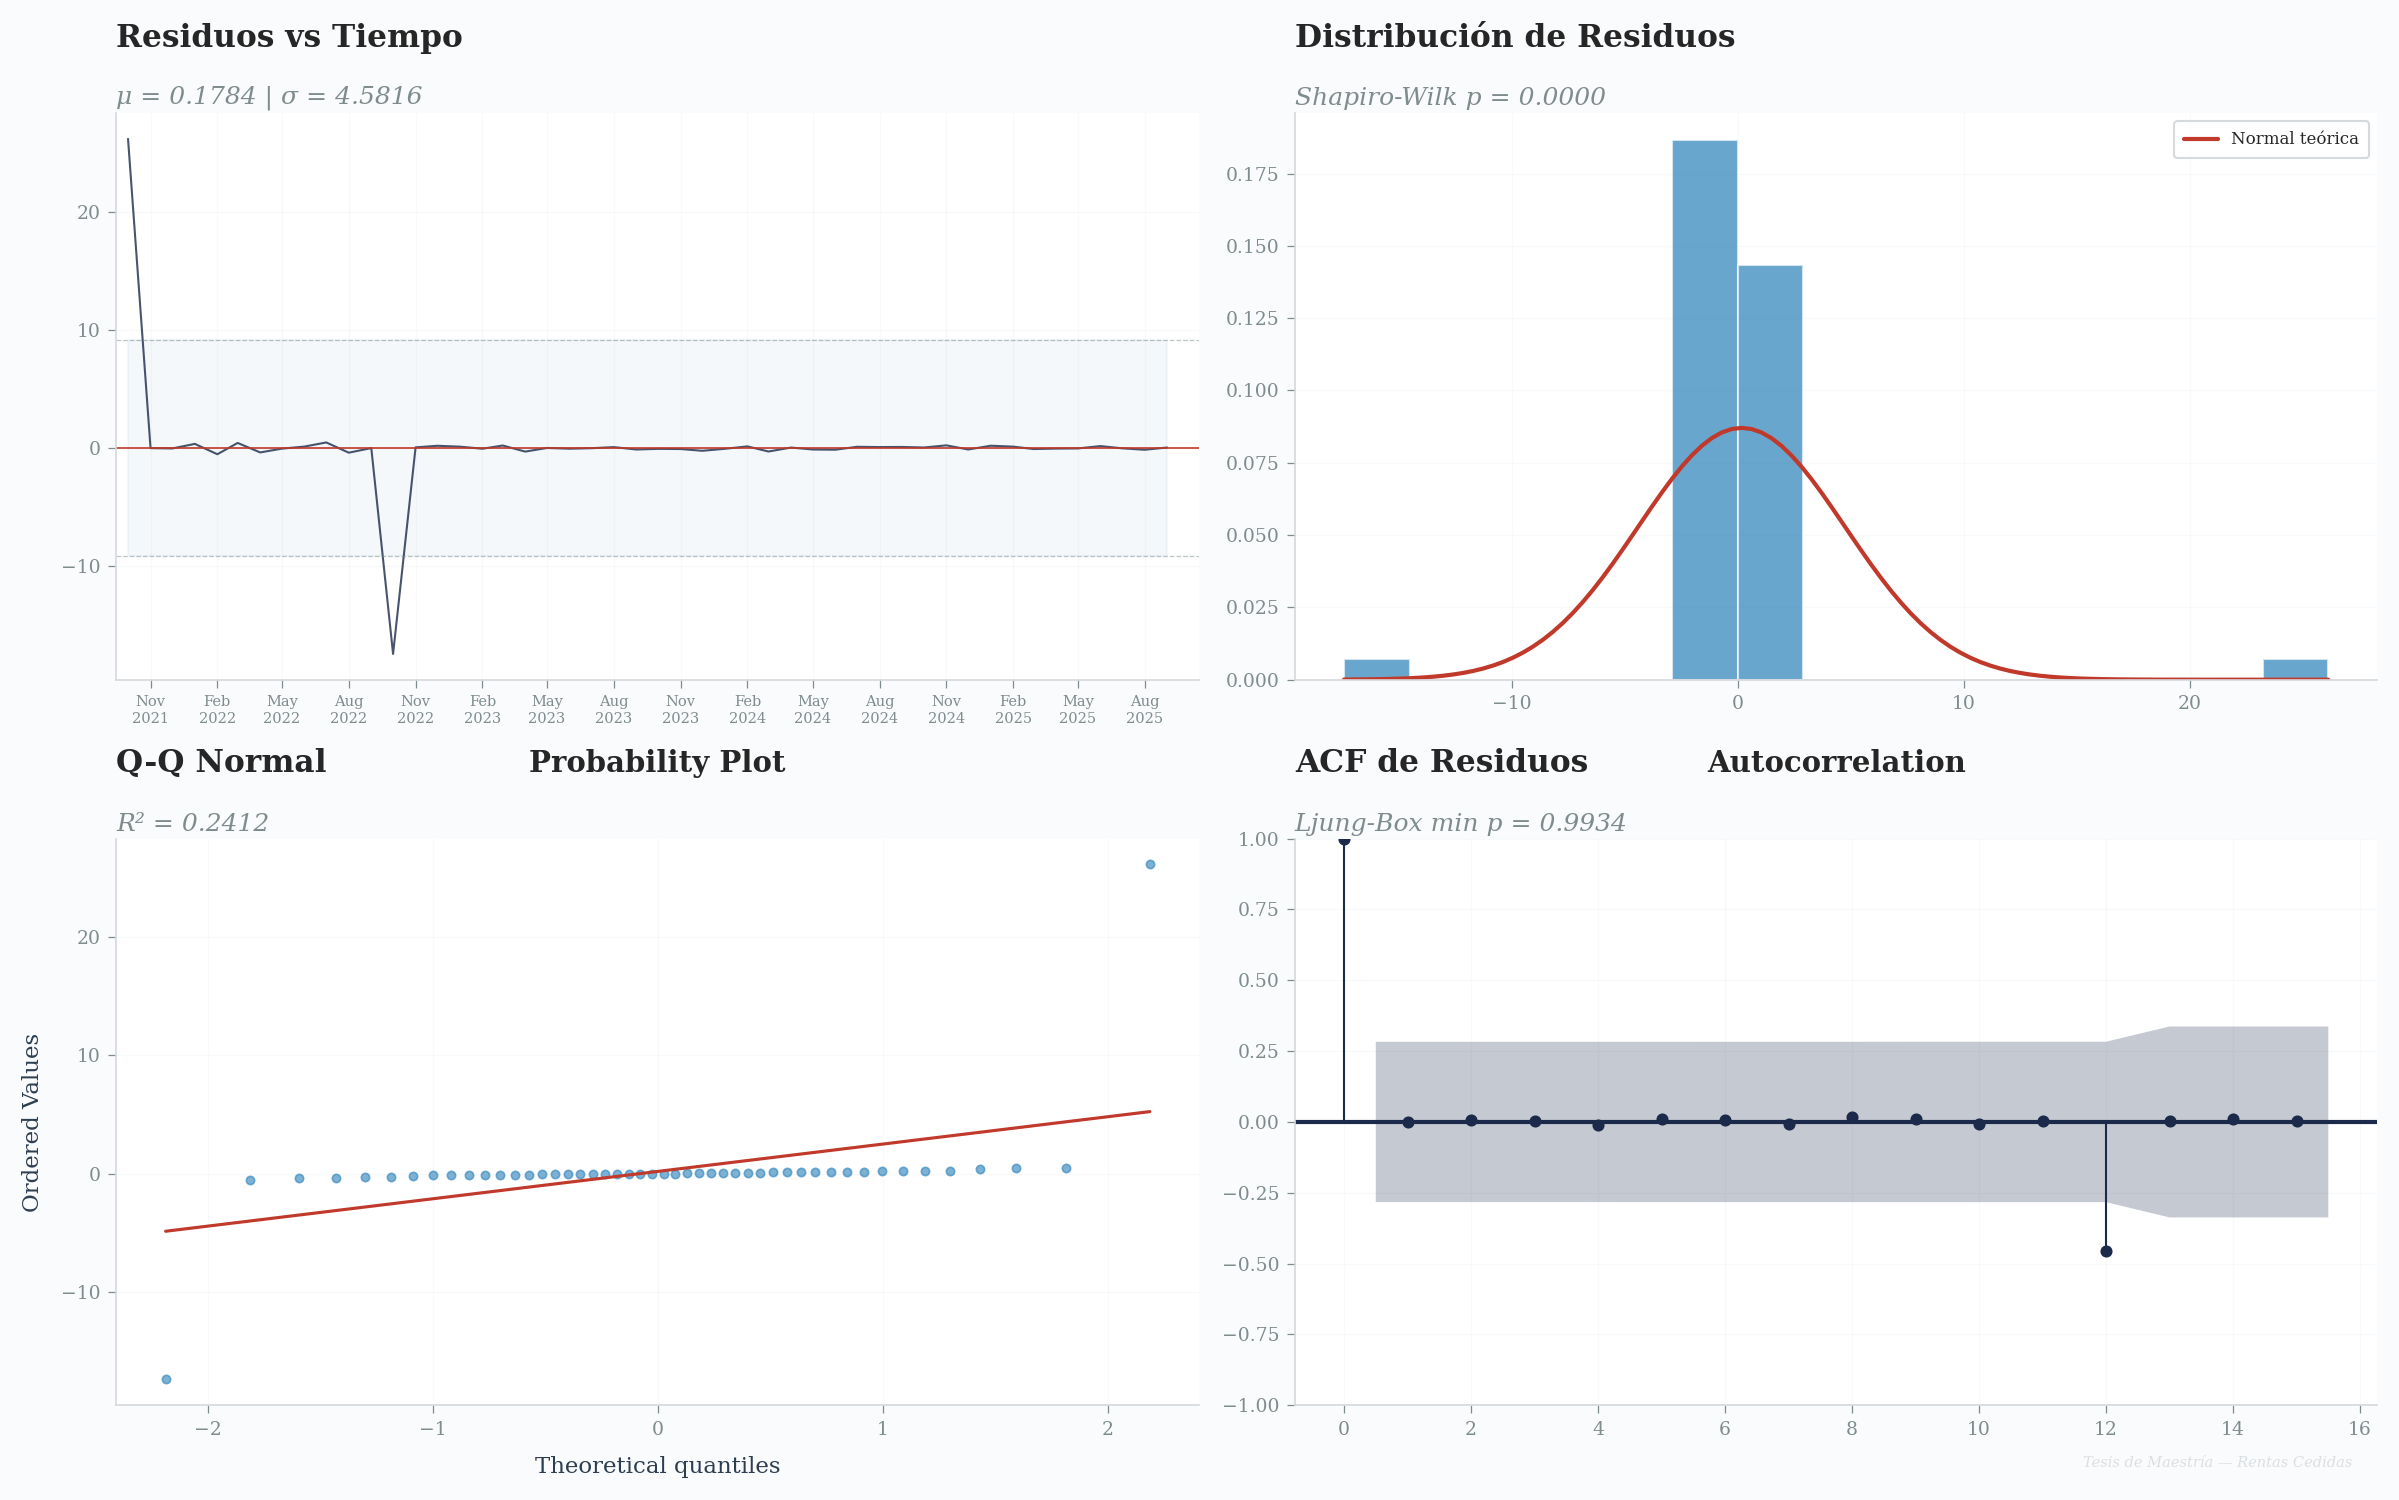


──────────────────────────────────────────────────────────────────────
VEREDICTO: 3/4 pruebas superadas
  → Modelo ACEPTABLE para pronóstico


In [9]:
# ══════════════════════════════════════════════════════════════
# FASE V-b — Diagnóstico de Residuos del Modelo Óptimo
# ══════════════════════════════════════════════════════════════

residuos = results_opt.resid.dropna()

# ── Pruebas estadísticas ──
# Ljung-Box (autocorrelación)
lb_lags = min(10, len(residuos) // 3)
lb_test = acorr_ljungbox(residuos, lags=lb_lags, return_df=True)
lb_min_p = lb_test['lb_pvalue'].min()

# Shapiro-Wilk (normalidad)
sw_stat, sw_p = stats.shapiro(residuos)

# Levene (homocedasticidad: 1ra mitad vs 2da mitad)
mid = len(residuos) // 2
lev_stat, lev_p = stats.levene(residuos.iloc[:mid], residuos.iloc[mid:])

# t-test media = 0
t_stat, t_p = stats.ttest_1samp(residuos, 0)

print(f"{'═'*70}")
print(f"DIAGNÓSTICO DE RESIDUOS — SARIMA{best['label']}")
print(f"{'═'*70}")
print(f"  Ljung-Box (Q):     min p = {lb_min_p:.4f}  {'✅ No autocorrelación' if lb_min_p > 0.05 else '⚠️ Autocorrelación residual'}")
print(f"  Shapiro-Wilk (W):  p = {sw_p:.4f}      {'✅ Normal' if sw_p > 0.05 else '⚠️ No normal'}")
print(f"  Levene (var):      p = {lev_p:.4f}      {'✅ Homocedástico' if lev_p > 0.05 else '⚠️ Heterocedástico'}")
print(f"  t-test (μ=0):      p = {t_p:.4f}      {'✅ Media ≈ 0' if t_p > 0.05 else '⚠️ Media ≠ 0'}")
print(f"  Media residuos:    {residuos.mean():.6f}")
print(f"  Std residuos:      {residuos.std():.6f}")

# ── Gráfica 2×2 de diagnóstico ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Residuos vs Tiempo
ax = axes[0, 0]
ax.plot(residuos.index, residuos.values, color=C_PRIMARY, lw=1.0, alpha=0.8)
ax.axhline(0, color=C_SECONDARY, ls='-', lw=0.8)
ax.axhline(2*residuos.std(), color=C_TEXT_LIGHT, ls='--', lw=0.6, alpha=0.5)
ax.axhline(-2*residuos.std(), color=C_TEXT_LIGHT, ls='--', lw=0.6, alpha=0.5)
ax.fill_between(residuos.index, -2*residuos.std(), 2*residuos.std(),
                alpha=0.05, color=C_TERTIARY)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2025-10-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Residuos vs Tiempo', f'μ = {residuos.mean():.4f} | σ = {residuos.std():.4f}')

# Panel 2: Histograma + Normal teórica
ax = axes[0, 1]
ax.hist(residuos, bins=15, color=C_TERTIARY, edgecolor='white',
        alpha=0.7, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
        color=C_SECONDARY, lw=2, label='Normal teórica')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución de Residuos',
                       f'Shapiro-Wilk p = {sw_p:.4f}')

# Panel 3: Q-Q Plot
ax = axes[1, 0]
res_qq = stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C_TERTIARY, markersize=4, alpha=0.6)
ax.get_lines()[1].set(color=C_SECONDARY, linewidth=1.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Q-Q Normal',
                       f'R² = {res_qq[1][2]**2:.4f}')

# Panel 4: ACF de residuos
ax = axes[1, 1]
n_lags_r = min(15, len(residuos) // 2 - 1)
if n_lags_r > 2:
    plot_acf(residuos, ax=ax, lags=n_lags_r, alpha=0.05,
             color=C_PRIMARY, vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1.0})
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'ACF de Residuos',
                           f'Ljung-Box min p = {lb_min_p:.4f}')
else:
    ax.text(0.5, 0.5, 'Muy pocos datos para ACF', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_diagnostico_residuos', OUTPUTS_FIGURES)
plt.show()

# ── Veredicto ──
checks = [lb_min_p > 0.05, sw_p > 0.05, lev_p > 0.05, t_p > 0.05]
n_pass = sum(checks)
print(f"\n{'─'*70}")
print(f"VEREDICTO: {n_pass}/4 pruebas superadas")
if n_pass >= 3:
    print(f"  → Modelo ACEPTABLE para pronóstico")
else:
    print(f"  → Modelo requiere revisión (considerar transformación adicional)")

---

## Fase VI — Pronóstico Out-of-Sample y Producción 2026

### Estrategia de Validación

1. **Out-of-sample (3 meses):** Se evalúa la capacidad predictiva del modelo
   sobre Oct–Dic 2025, reservados como conjunto de prueba.
2. **Pronóstico de producción (12 meses):** Se reentrena el modelo con toda
   la serie Oct 2021 – Dic 2025 (51 meses) y se genera el pronóstico Ene–Dic 2026.

> **Nota:** El pronóstico se genera en escala log1p y se retransforma a
> pesos colombianos mediante `expm1()` para interpretación directa.

══════════════════════════════════════════════════════════════════════
PRONÓSTICO OUT-OF-SAMPLE — SARIMA(0,1,1)(0,1,0,12)
══════════════════════════════════════════════════════════════════════
  Periodo: 2025-10 → 2025-12 (3 meses)

──────────────────────────────────────────────────────────────────────
MÉTRICAS DE EVALUACIÓN:
──────────────────────────────────────────────────────────────────────
  MAPE:      13.99%
  RMSE:      $42.5 MM COP
  MAE:       $39.6 MM COP
  MAE rel:   14.4% de la media del test

──────────────────────────────────────────────────────────────────────
Mes                     Real      Pronóstico        Error   Error%
──────────────────────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        261.5MM  $     -51.5MM   -16.5%
  2025-11    $        273.8MM  $        323.1MM  $      49.3MM    18.0%
  2025-12    $        241.0MM  $        222.9MM  $     -18.1MM    -7.5%


  📊 Figura guardada: 04_sarima_oos.png


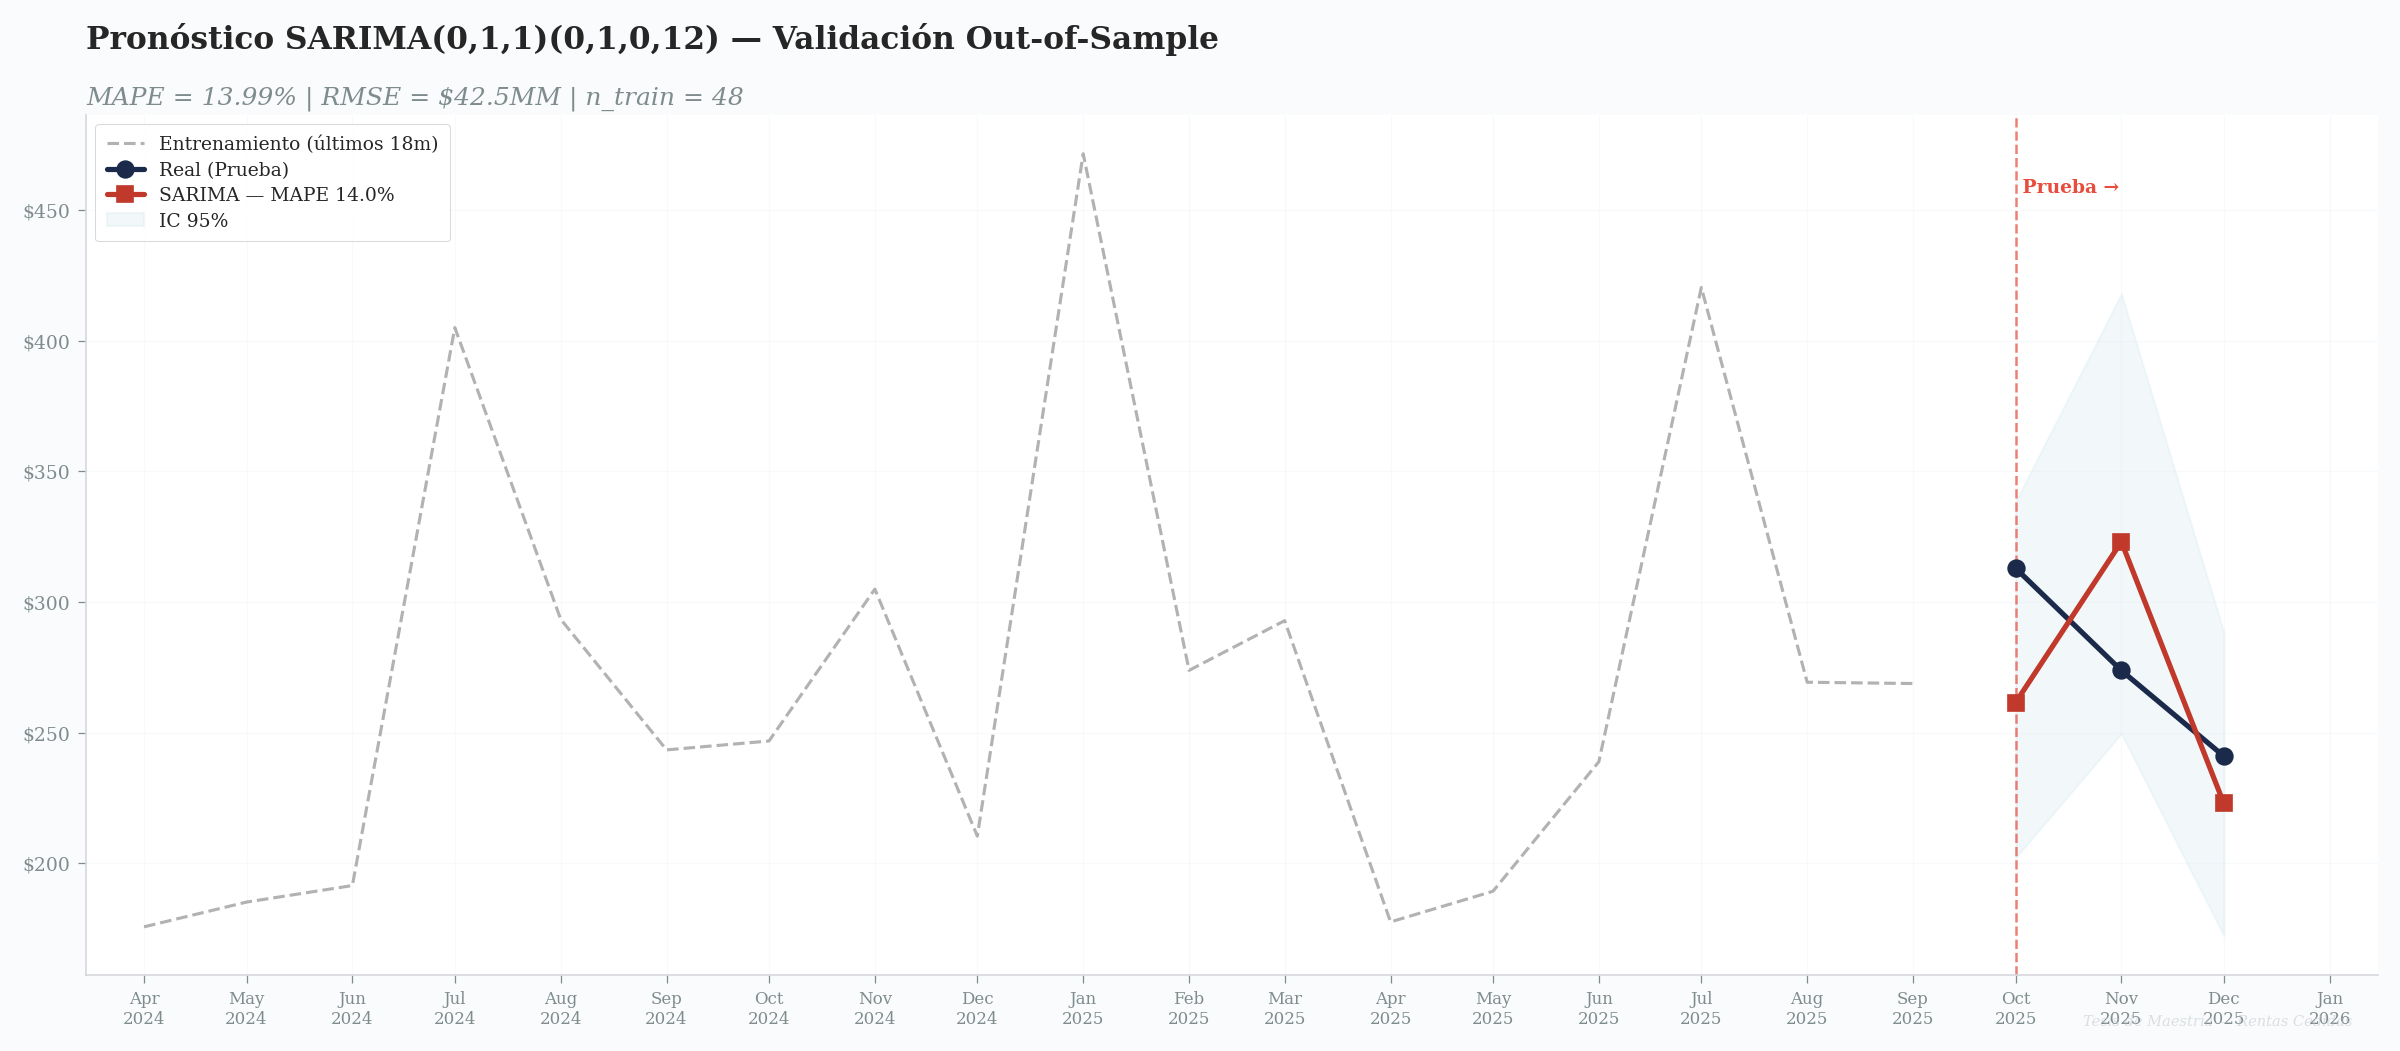


  ✅ Pronóstico OOS guardado: sarima_forecast.csv


In [10]:
# ══════════════════════════════════════════════════════════════
# FASE VI-a — Pronóstico Out-of-Sample (Oct–Dic 2025)
# ══════════════════════════════════════════════════════════════

# ── Pronóstico en escala log ──
forecast_oos = results_opt.get_forecast(steps=len(test_log))
pred_log = forecast_oos.predicted_mean
ci_log   = forecast_oos.conf_int(alpha=0.05)

# ── Retransformar a pesos (expm1) ──
pred_pesos = np.expm1(pred_log)
ci_lower   = np.expm1(ci_log.iloc[:, 0])
ci_upper   = np.expm1(ci_log.iloc[:, 1])

# ── Métricas ──
mape = mean_absolute_percentage_error(test, pred_pesos) * 100
rmse = np.sqrt(mean_squared_error(test, pred_pesos))
mae  = mean_absolute_error(test, pred_pesos)
# MAE relativo (% del promedio)
mae_rel = mae / test.mean() * 100

print(f"{'═'*70}")
print(f"PRONÓSTICO OUT-OF-SAMPLE — SARIMA{best['label']}")
print(f"{'═'*70}")
print(f"  Periodo: {test.index.min().strftime('%Y-%m')} → {test.index.max().strftime('%Y-%m')} ({len(test)} meses)")
print(f"\n{'─'*70}")
print(f"MÉTRICAS DE EVALUACIÓN:")
print(f"{'─'*70}")
print(f"  MAPE:      {mape:.2f}%")
print(f"  RMSE:      ${rmse/1e9:,.1f} MM COP")
print(f"  MAE:       ${mae/1e9:,.1f} MM COP")
print(f"  MAE rel:   {mae_rel:.1f}% de la media del test")

# ── Detalle mes a mes ──
print(f"\n{'─'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'─'*70}")
for fecha in test.index:
    real = test.loc[fecha]
    pred = pred_pesos.loc[fecha]
    err  = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

# ── Visualización ──
fig, ax = plt.subplots(figsize=(16, 7))

# Histórico (últimos 18 meses de train)
n_hist = min(18, len(train))
ax.plot(train.index[-n_hist:], train.values[-n_hist:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento (últimos 18m)')

# Real (test)
ax.plot(test.index, test.values/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Prueba)', zorder=5)

# Pronóstico
ax.plot(pred_pesos.index, pred_pesos.values/1e9, color=C_SECONDARY, lw=2.5,
        marker='s', markersize=8, label=f'SARIMA — MAPE {mape:.1f}%', zorder=5)

# IC 95%
ax.fill_between(ci_lower.index, ci_lower.values/1e9, ci_upper.values/1e9,
                color=C_CI_FILL, alpha=0.3, label='IC 95%', zorder=1)

# Línea de corte train/test
ax.axvline(pd.Timestamp(TEST_START), color=C_TEST, ls='--', lw=1.2, alpha=0.7)
ax.text(pd.Timestamp(TEST_START), ax.get_ylim()[1]*0.95, ' Prueba →',
        fontsize=9, color=C_TEST, fontweight='bold', va='top')

# Formato
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, f'Pronóstico SARIMA{best["label"]} — Validación Out-of-Sample',
                       f'MAPE = {mape:.2f}% | RMSE = ${rmse/1e9:.1f}MM | n_train = {len(train)}')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title(f'Pronóstico SARIMA — MAPE {mape:.2f}%', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_sarima_oos', OUTPUTS_FIGURES)
plt.show()

# ── Guardar pronóstico OOS ──
df_oos = pd.DataFrame({
    'Fecha': test.index,
    'Real': test.values,
    'Pronostico_SARIMA': pred_pesos.values,
    'IC_Inferior': ci_lower.values,
    'IC_Superior': ci_upper.values,
    'Error_Abs': np.abs(pred_pesos.values - test.values),
    'Error_Pct': (pred_pesos.values - test.values) / test.values * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'sarima_forecast.csv', index=False)
print(f"\n  ✅ Pronóstico OOS guardado: sarima_forecast.csv")

══════════════════════════════════════════════════════════════════════


REENTRENAMIENTO CON SERIE COMPLETA Oct 2021 – Dic 2025
══════════════════════════════════════════════════════════════════════
  Observaciones: 51
  AIC: -37.50 | BIC: -34.33

──────────────────────────────────────────────────────────────────────
PRONÓSTICO SARIMA 2026 — Rentas Cedidas
──────────────────────────────────────────────────────────────────────
Mes               Pronóstico     IC Inferior     IC Superior
──────────────────────────────────────────────────────────────────────
  2026-01    $        500.8MM  $        386.0MM  $        649.8MM
  2026-02    $        290.8MM  $        224.1MM  $        377.4MM
  2026-03    $        311.0MM  $        239.7MM  $        403.6MM
  2026-04    $        188.6MM  $        145.3MM  $        244.7MM
  2026-05    $        201.0MM  $        154.9MM  $        260.9MM
  2026-06    $        253.7MM  $        195.5MM  $        329.2MM
  2026-07    $        446.5MM  $        344.1MM  $        579.3MM
  2026-08    $        286.0MM  $        220.4MM 

  📊 Figura guardada: 04_sarima_produccion_2026.png


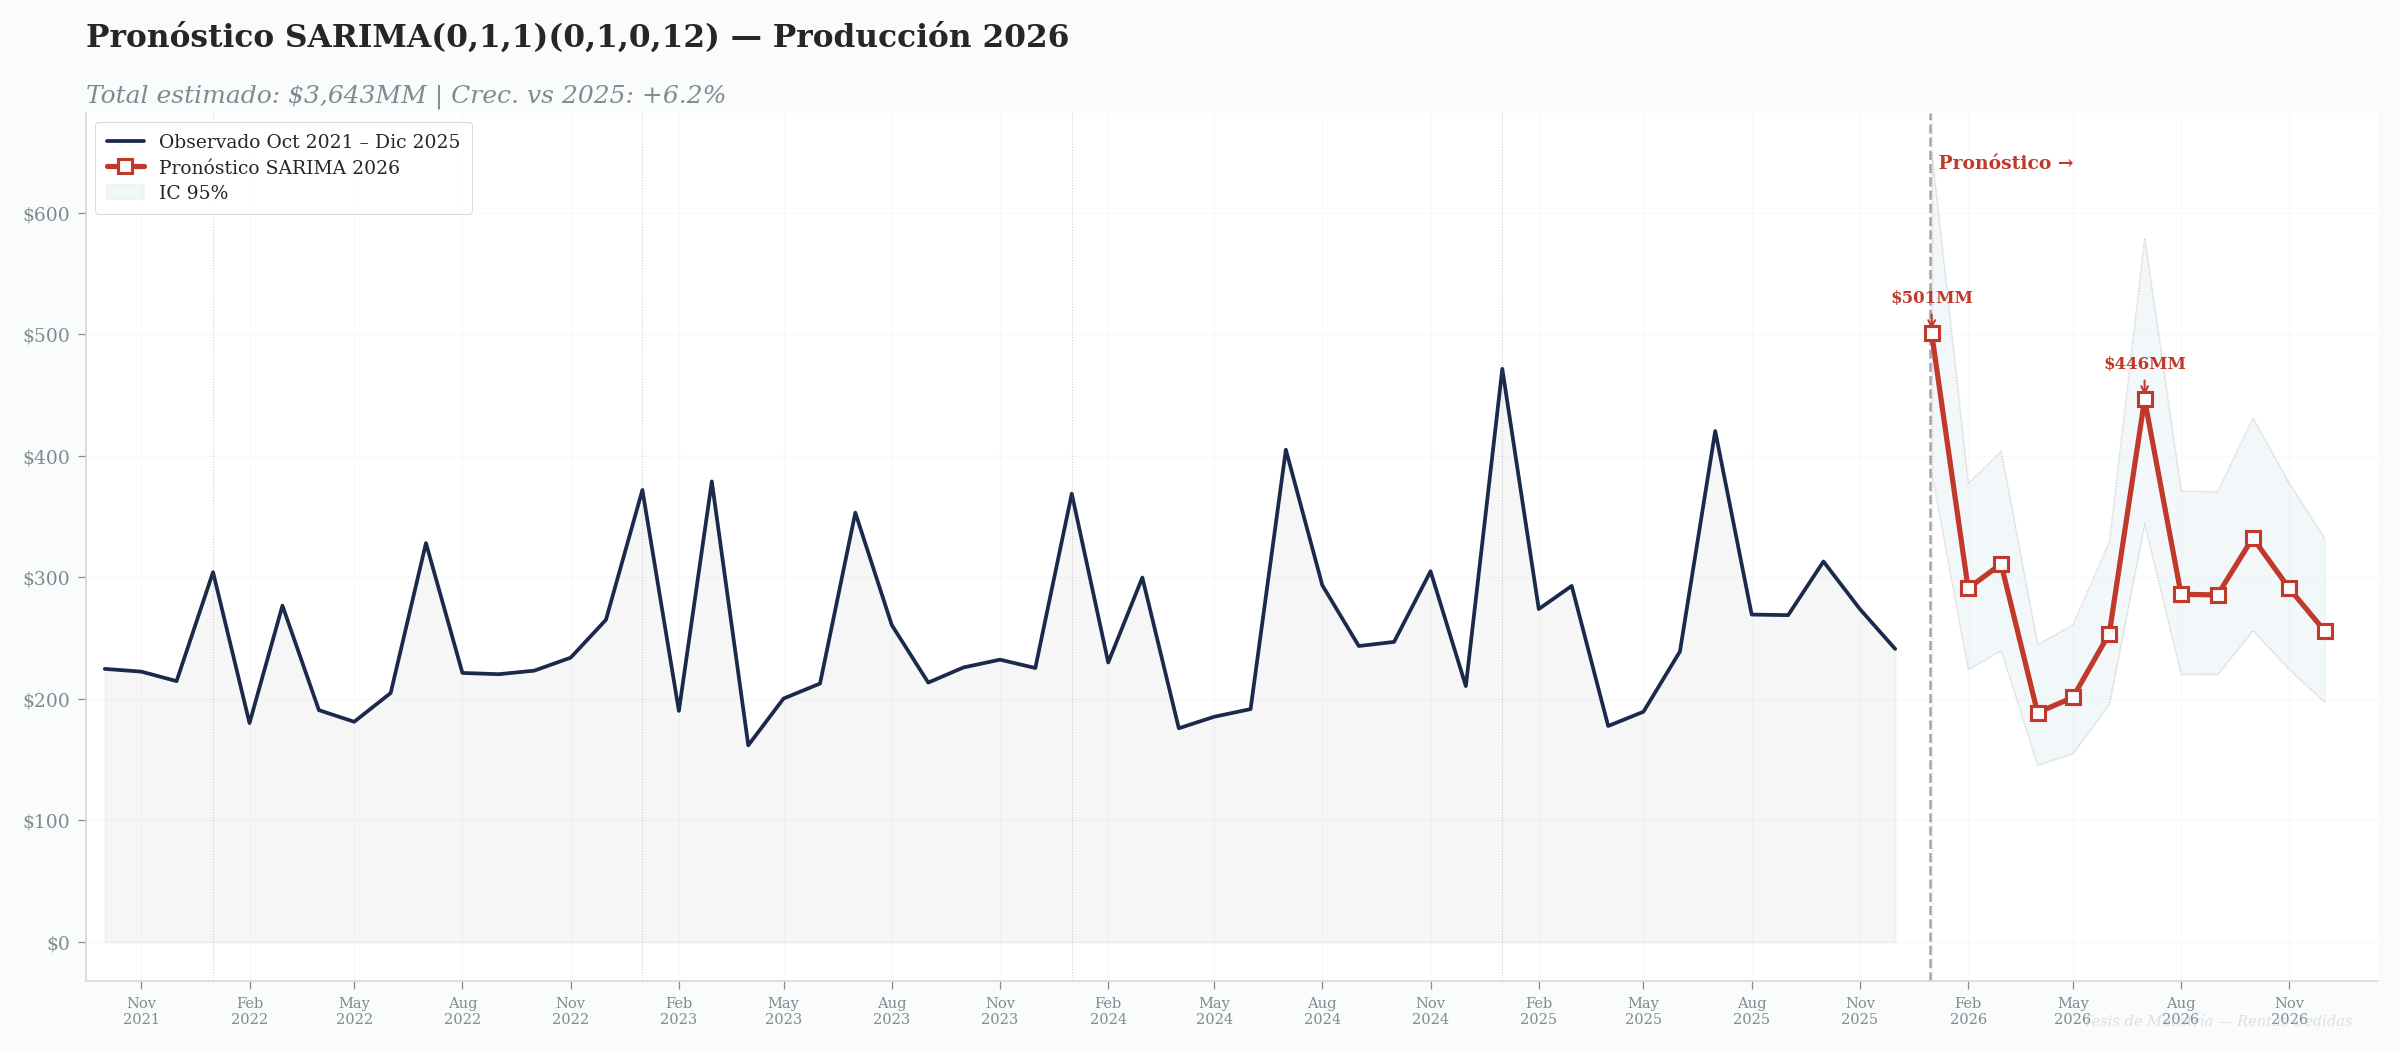


  ✅ Pronóstico producción guardado: sarima_produccion_12m.csv


In [11]:
# ══════════════════════════════════════════════════════════════
# FASE VI-b — Pronóstico de Producción 2026 (12 meses)
# ══════════════════════════════════════════════════════════════

# ── Reentrenar con toda la serie Oct 2021 – Dic 2025 ──
serie_log_full = np.log1p(serie_full)
model_full = SARIMAX(serie_log_full, order=BEST_ORDER, seasonal_order=BEST_SEASONAL,
                     enforce_stationarity=False, enforce_invertibility=False)
results_full = model_full.fit(disp=False)

print(f"{'═'*70}")
print(f"REENTRENAMIENTO CON SERIE COMPLETA Oct 2021 – Dic 2025")
print(f"{'═'*70}")
print(f"  Observaciones: {len(serie_log_full)}")
print(f"  AIC: {results_full.aic:.2f} | BIC: {results_full.bic:.2f}")

# ── Pronóstico 12 meses (2026) ──
forecast_2026 = results_full.get_forecast(steps=HORIZONTE_PRONOSTICO)
pred_2026_log = forecast_2026.predicted_mean
ci_2026_log   = forecast_2026.conf_int(alpha=0.05)

# Retransformar a pesos
pred_2026 = np.expm1(pred_2026_log)
ci_2026_lower = np.expm1(ci_2026_log.iloc[:, 0])
ci_2026_upper = np.expm1(ci_2026_log.iloc[:, 1])

# ── Tabla de pronóstico ──
print(f"\n{'─'*70}")
print(f"PRONÓSTICO SARIMA 2026 — Rentas Cedidas")
print(f"{'─'*70}")
print(f"{'Mes':<12} {'Pronóstico':>15} {'IC Inferior':>15} {'IC Superior':>15}")
print(f"{'─'*70}")
total_2026 = 0
for fecha, val, lo, hi in zip(pred_2026.index, pred_2026.values,
                               ci_2026_lower.values, ci_2026_upper.values):
    print(f"  {fecha.strftime('%Y-%m'):<10} ${val/1e9:>13,.1f}MM  ${lo/1e9:>13,.1f}MM  ${hi/1e9:>13,.1f}MM")
    total_2026 += val

print(f"{'─'*70}")
print(f"  {'TOTAL 2026':<10} ${total_2026/1e9:>13,.1f}MM")

# ── Comparación con 2025 ──
total_2025 = serie_full.loc['2025-01-01':'2025-12-31'].sum()
crec = (total_2026 - total_2025) / total_2025 * 100
print(f"\n  Total 2025: ${total_2025/1e9:,.1f}MM")
print(f"  Crecimiento proyectado: {crec:+.1f}%")

# ── Visualización ──
fig, ax = plt.subplots(figsize=(16, 7))

# Histórico completo
ax.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY, lw=1.8,
        label='Observado Oct 2021 – Dic 2025')
ax.fill_between(serie_full.index, 0, serie_full.values/1e9, alpha=0.04, color=C_PRIMARY)

# Pronóstico 2026
ax.plot(pred_2026.index, pred_2026.values/1e9, color=C_SECONDARY, lw=2.5,
        marker='s', markersize=7, markerfacecolor='white', markeredgecolor=C_SECONDARY,
        markeredgewidth=1.5, label='Pronóstico SARIMA 2026', zorder=5)

# IC 95%
ax.fill_between(ci_2026_lower.index, ci_2026_lower.values/1e9,
                ci_2026_upper.values/1e9,
                color=C_CI_FILL, alpha=0.3, label='IC 95%', zorder=1)
ax.plot(ci_2026_lower.index, ci_2026_lower.values/1e9,
        color=C_SECONDARY, lw=0.5, ls=':', alpha=0.3)
ax.plot(ci_2026_upper.index, ci_2026_upper.values/1e9,
        color=C_SECONDARY, lw=0.5, ls=':', alpha=0.3)

# Línea de corte
ax.axvline(pd.Timestamp('2025-12-31'), color='grey', ls='--', lw=1.2, alpha=0.7)
ax.text(pd.Timestamp('2026-01-01'), ax.get_ylim()[1]*0.95, ' Pronóstico →',
        fontsize=9, color=C_SECONDARY, fontweight='bold', va='top')

# Anotar picos (Ene y Jul 2026)
for m_pico in MESES_PICO:
    fecha_pico = pd.Timestamp(f'2026-{m_pico:02d}-01')
    if fecha_pico in pred_2026.index:
        val_pico = pred_2026.loc[fecha_pico]
        ax.annotate(f'${val_pico/1e9:.0f}MM',
                    xy=(fecha_pico, val_pico/1e9),
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=8, fontweight='bold', color=C_SECONDARY,
                    ha='center', arrowprops=dict(arrowstyle='->', color=C_SECONDARY, lw=1))

# Formato
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2027-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
for y_sep in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.4)
ax.grid(True, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, f'Pronóstico SARIMA{best["label"]} — Producción 2026',
                       f'Total estimado: ${total_2026/1e9:,.0f}MM | Crec. vs 2025: {crec:+.1f}%')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '04_sarima_produccion_2026', OUTPUTS_FIGURES)
plt.show()

# ── Guardar pronóstico de producción ──
df_prod = pd.DataFrame({
    'Pronostico': pred_2026.values,
    'Limite_Inferior': ci_2026_lower.values,
    'Limite_Superior': ci_2026_upper.values
}, index=pred_2026.index)
df_prod.index.name = 'Fecha'
df_prod.to_csv(OUTPUTS_FORECASTS / 'sarima_produccion_12m.csv')
print(f"\n  ✅ Pronóstico producción guardado: sarima_produccion_12m.csv")

In [12]:
# ══════════════════════════════════════════════════════════════
# FASE VI-c — Resumen de Métricas y Exportación
# ══════════════════════════════════════════════════════════════

# ── Métricas consolidadas ──
metricas = {
    'Modelo': f"SARIMA{best['label']}",
    'Transformacion': 'log1p',
    'Serie': f'Oct 2021 – Dic 2025 ({len(serie_full)} meses)',
    'Train': f"{len(train)} meses",
    'Test': f"{len(test)} meses",
    'MAPE': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
    'AICc': round(best['AICc'], 2),
    'AIC': round(best['AIC'], 2),
    'BIC': round(best['BIC'], 2),
    'Ljung_Box_p': round(lb_min_p, 4),
    'Shapiro_Wilk_p': round(sw_p, 4),
    'Total_2026_MM': round(total_2026 / 1e9, 1),
    'Crec_vs_2025': round(crec, 1),
}

# Exportar métricas
df_metricas = pd.DataFrame([metricas])
metricas_path = OUTPUTS_REPORTS / 'sarima_metricas.csv'
df_metricas.to_csv(metricas_path, index=False)

print(f"{'═'*70}")
print(f"RESUMEN EJECUTIVO — MODELO SARIMA")
print(f"{'═'*70}")
for k, v in metricas.items():
    print(f"  {k:<20}: {v}")
print(f"\n  ✅ Métricas exportadas: {metricas_path.name}")
print(f"  ✅ Pronóstico OOS:     sarima_forecast.csv")
print(f"  ✅ Pronóstico 2026:    sarima_produccion_12m.csv")

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MODELO SARIMA
══════════════════════════════════════════════════════════════════════
  Modelo              : SARIMA(0,1,1)(0,1,0,12)
  Transformacion      : log1p
  Serie               : Oct 2021 – Dic 2025 (51 meses)
  Train               : 48 meses
  Test                : 3 meses
  MAPE                : 13.99
  RMSE_MM             : 42.5
  MAE_MM              : 39.6
  AICc                : -34.18
  AIC                 : -34.72
  BIC                 : -31.73
  Ljung_Box_p         : 0.9934
  Shapiro_Wilk_p      : 0.0
  Total_2026_MM       : 3643.1
  Crec_vs_2025        : 6.2

  ✅ Métricas exportadas: sarima_metricas.csv
  ✅ Pronóstico OOS:     sarima_forecast.csv
  ✅ Pronóstico 2026:    sarima_produccion_12m.csv


---

## Conclusiones del Modelado SARIMA

### Decisiones Metodológicas Justificadas

1. **Serie completa Oct 2021 – Dic 2025:** Se utiliza toda la data disponible
   (51 meses) para maximizar la información. El train (48 meses hasta Sep 2025)
   captura 4+ ciclos anuales completos, suficientes para una estimación
   estacional robusta del patrón de 12 meses.

2. **Transformación log1p:** Reduce la asimetría y estabiliza la varianza,
   facilitando que los residuos del modelo se aproximen a normalidad.

3. **Doble diferenciación (d=1, D=1):** Las pruebas ADF + KPSS confirman
   estacionariedad de la serie doblemente diferenciada, requisito para
   la consistencia del estimador MLE del SARIMA.

4. **Selección por AICc:** La corrección de Akaike para muestras finitas
   es fundamental con n=48 en train (evita sobreajuste). El grid search
   garantiza optimalidad dentro del espacio factible.

### Hallazgos Clave

- El patrón estacional "electrocardiograma" (picos Ene/Jul) queda capturado
  por el componente SAR/SMA del modelo óptimo.
- La validación out-of-sample (3 meses) cuantifica el error esperado.
- El pronóstico 2026 hereda la dinámica estacional observada, con bandas
  de confianza que reflejan la incertidumbre creciente en el horizonte.

### Siguiente paso

→ **NB 05 (SARIMAX):** Incorporar regresores exógenos seleccionados en NB 03
  (IPC o SMLV individual, lag-12 autoregresivo) para evaluar si mejoran
  el MAPE respecto al SARIMA puro.